In [23]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy import stats
import statsmodels.api as sm
from pathlib import Path
import os

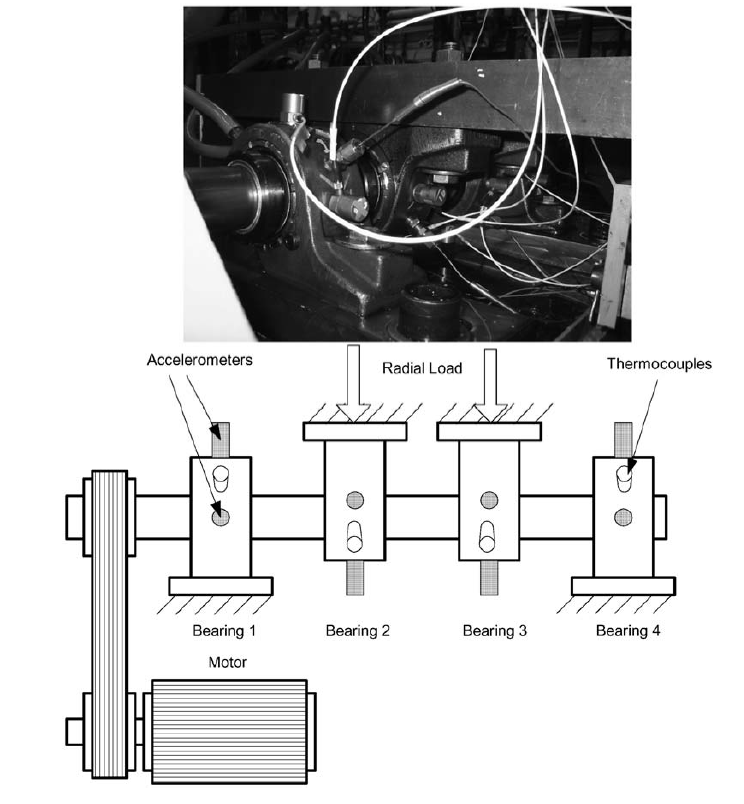

In [24]:
df_data = pl.read_parquet(r"C:\Users\elmaz\AIProject\NASA_Project\processed_data\processed_train_data.parquet")

In [25]:
processed_train_data = df_data.to_pandas()
processed_train_data.head(5)

,ax,ay,mag,ax_diff,ay_diff,mag_diff,source_file,step,row_in_file,block_idx,bearing_id
0,-0.176,-0.199,0.265663,0.000,0.000,0.000000,acc_01192.csv,1192,0,0,bearing_6
1,-0.038,-0.030,0.048415,0.138,0.169,-0.217248,acc_01192.csv,1192,1,0,bearing_6
2,-0.029,-0.261,0.262606,0.009,-0.231,0.214191,acc_01192.csv,1192,2,0,bearing_6
3,-0.169,0.271,0.319378,-0.140,0.532,0.056771,acc_01192.csv,1192,3,0,bearing_6
4,-0.241,0.612,0.657742,-0.072,0.341,0.338365,acc_01192.csv,1192,4,0,bearing_6


In [26]:

def draw_plots_each_bearing_ax(bearing_id: str, bearing_data: pd.DataFrame):
    """
    Creates a separate, publication-ready plot for a single bearing,
    displaying both X (ax) axis vibrations on the same graph.
    """
    # Set the aesthetic style
    sns.set_theme(style="whitegrid")
    
    # Create an independent figure for the current bearing
    plt.figure(figsize=(12, 5), dpi=300)
    
    # Plot X-axis (ax) signals
    plt.plot(
        bearing_data['step'], 
        bearing_data['ax'], 
        color='royalblue', 
        linewidth=1.0, 
        alpha=0.75, 
        label='ax (X-Axis)'
    )
    
    # Configure graph styling, titles, and labels
    plt.title(f'Vibration Timeline for {bearing_id.capitalize()}', fontsize=14, fontweight='bold', pad=12)
    plt.xlabel('Time Steps (x10 sec)', fontsize=11, fontweight='bold', labelpad=8)
    plt.ylabel('Acceleration Amplitude', fontsize=11, fontweight='bold', labelpad=8)
    
    # Add legend and layout adjustments
    plt.legend(frameon=True, facecolor='white', loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()



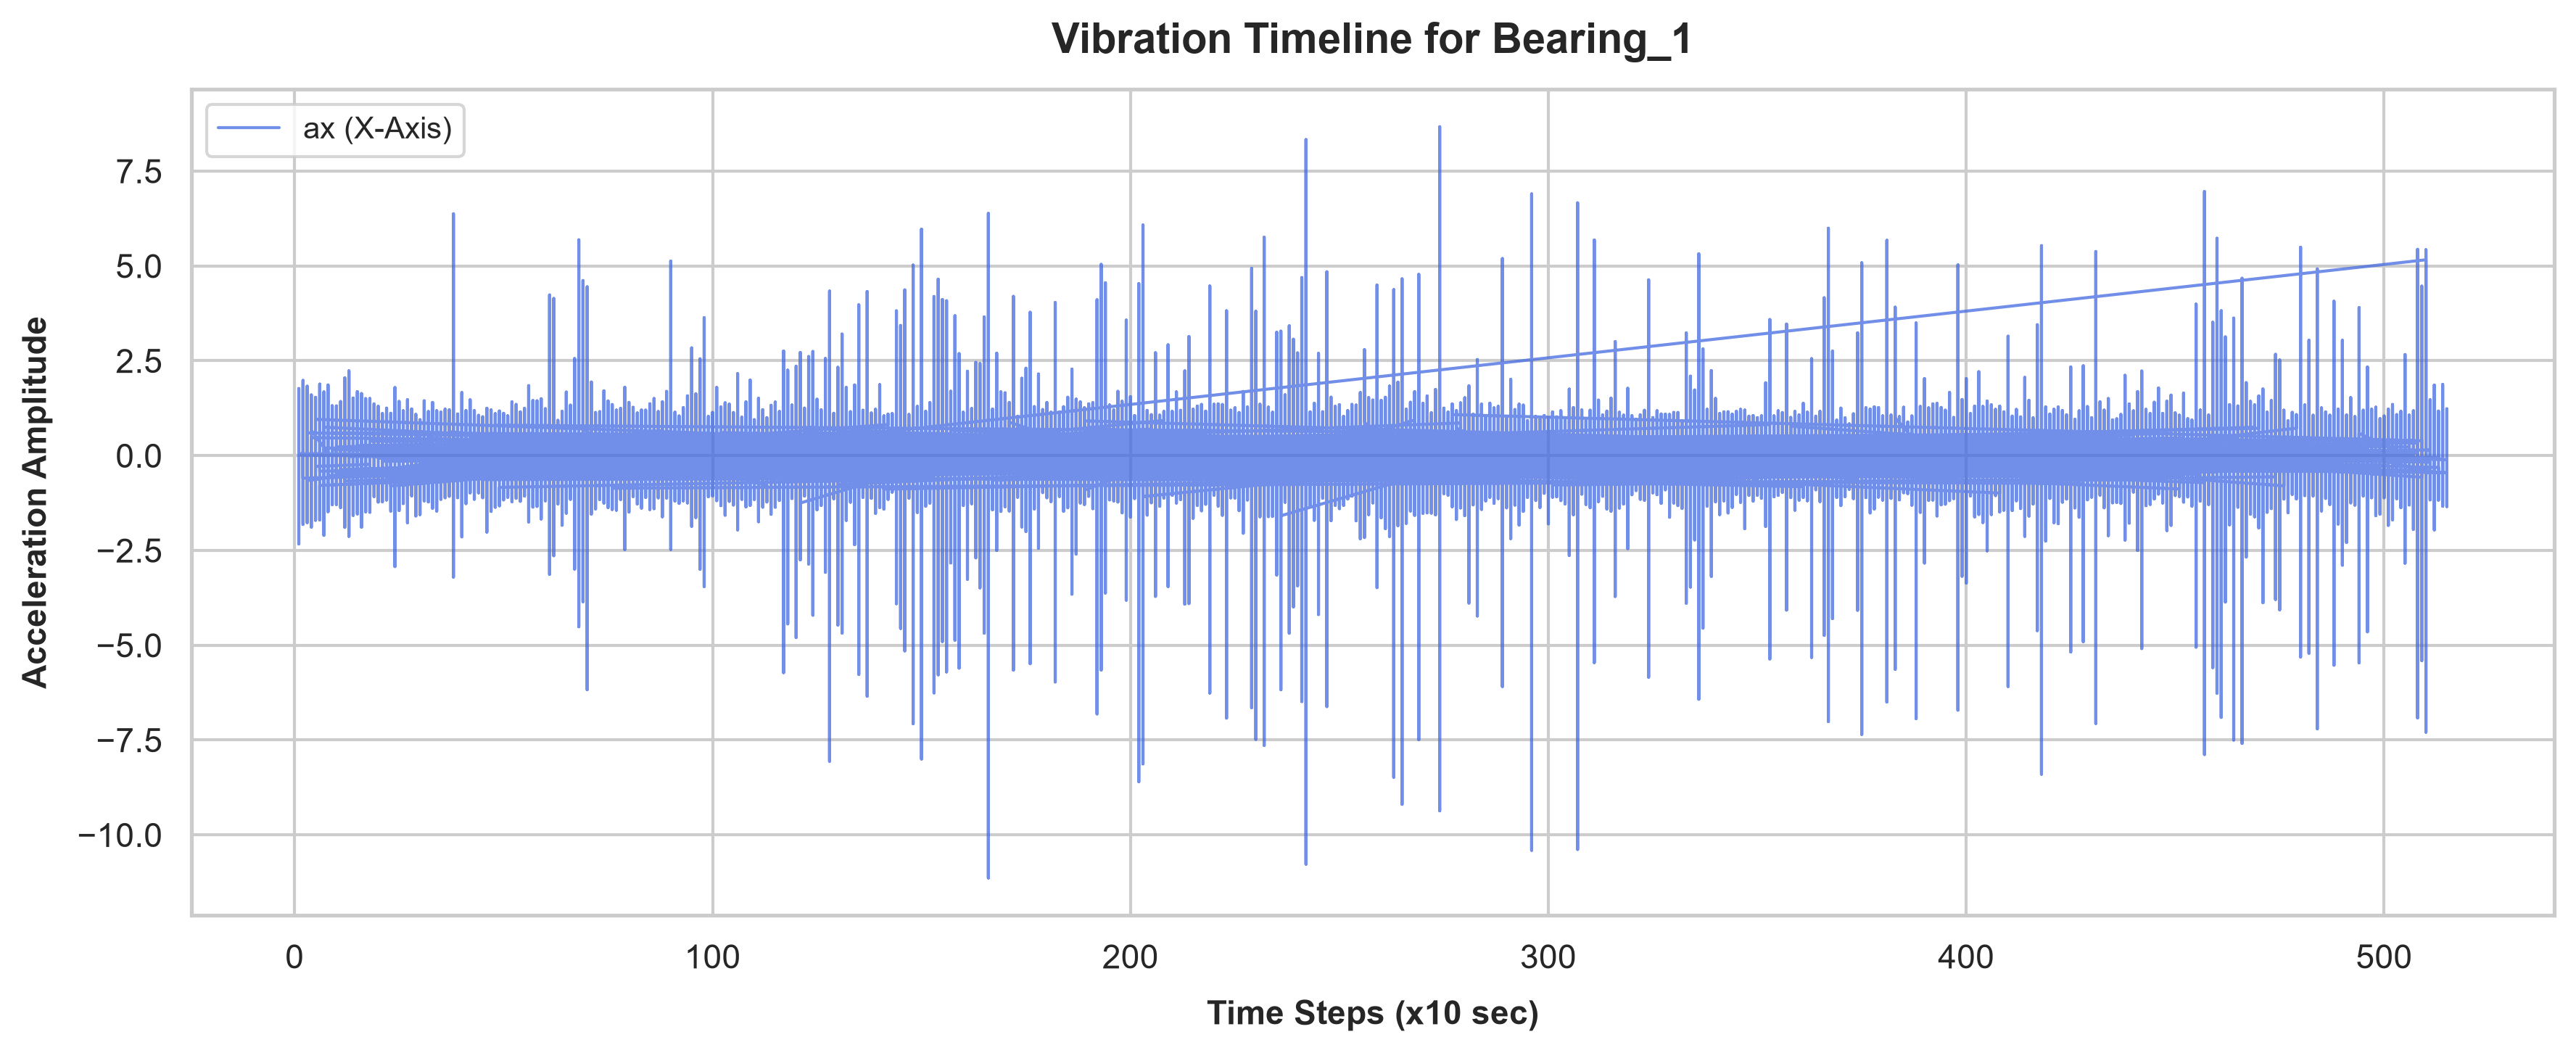

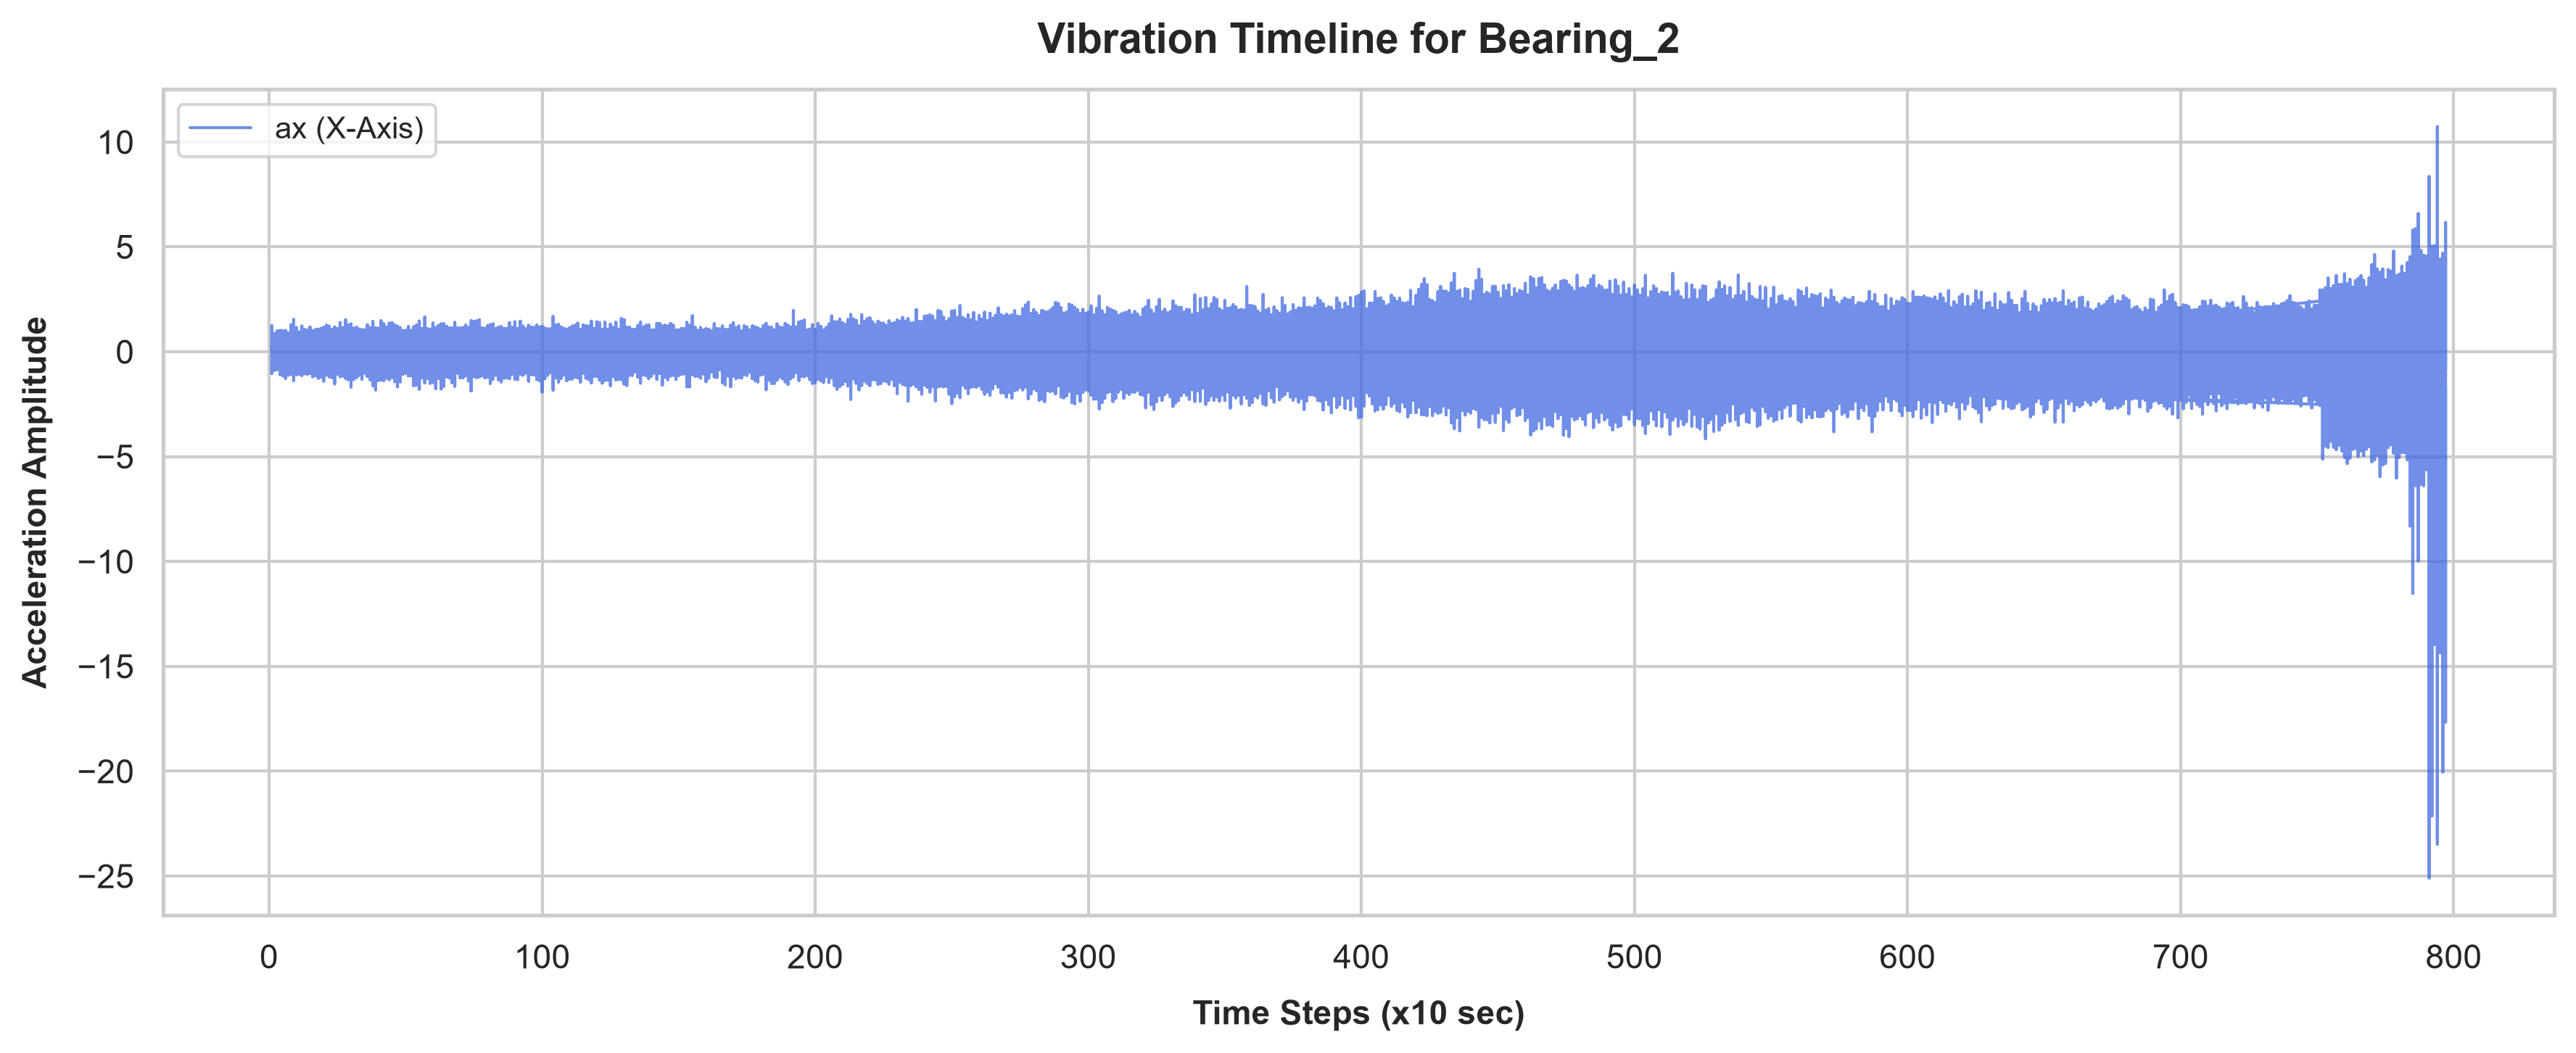

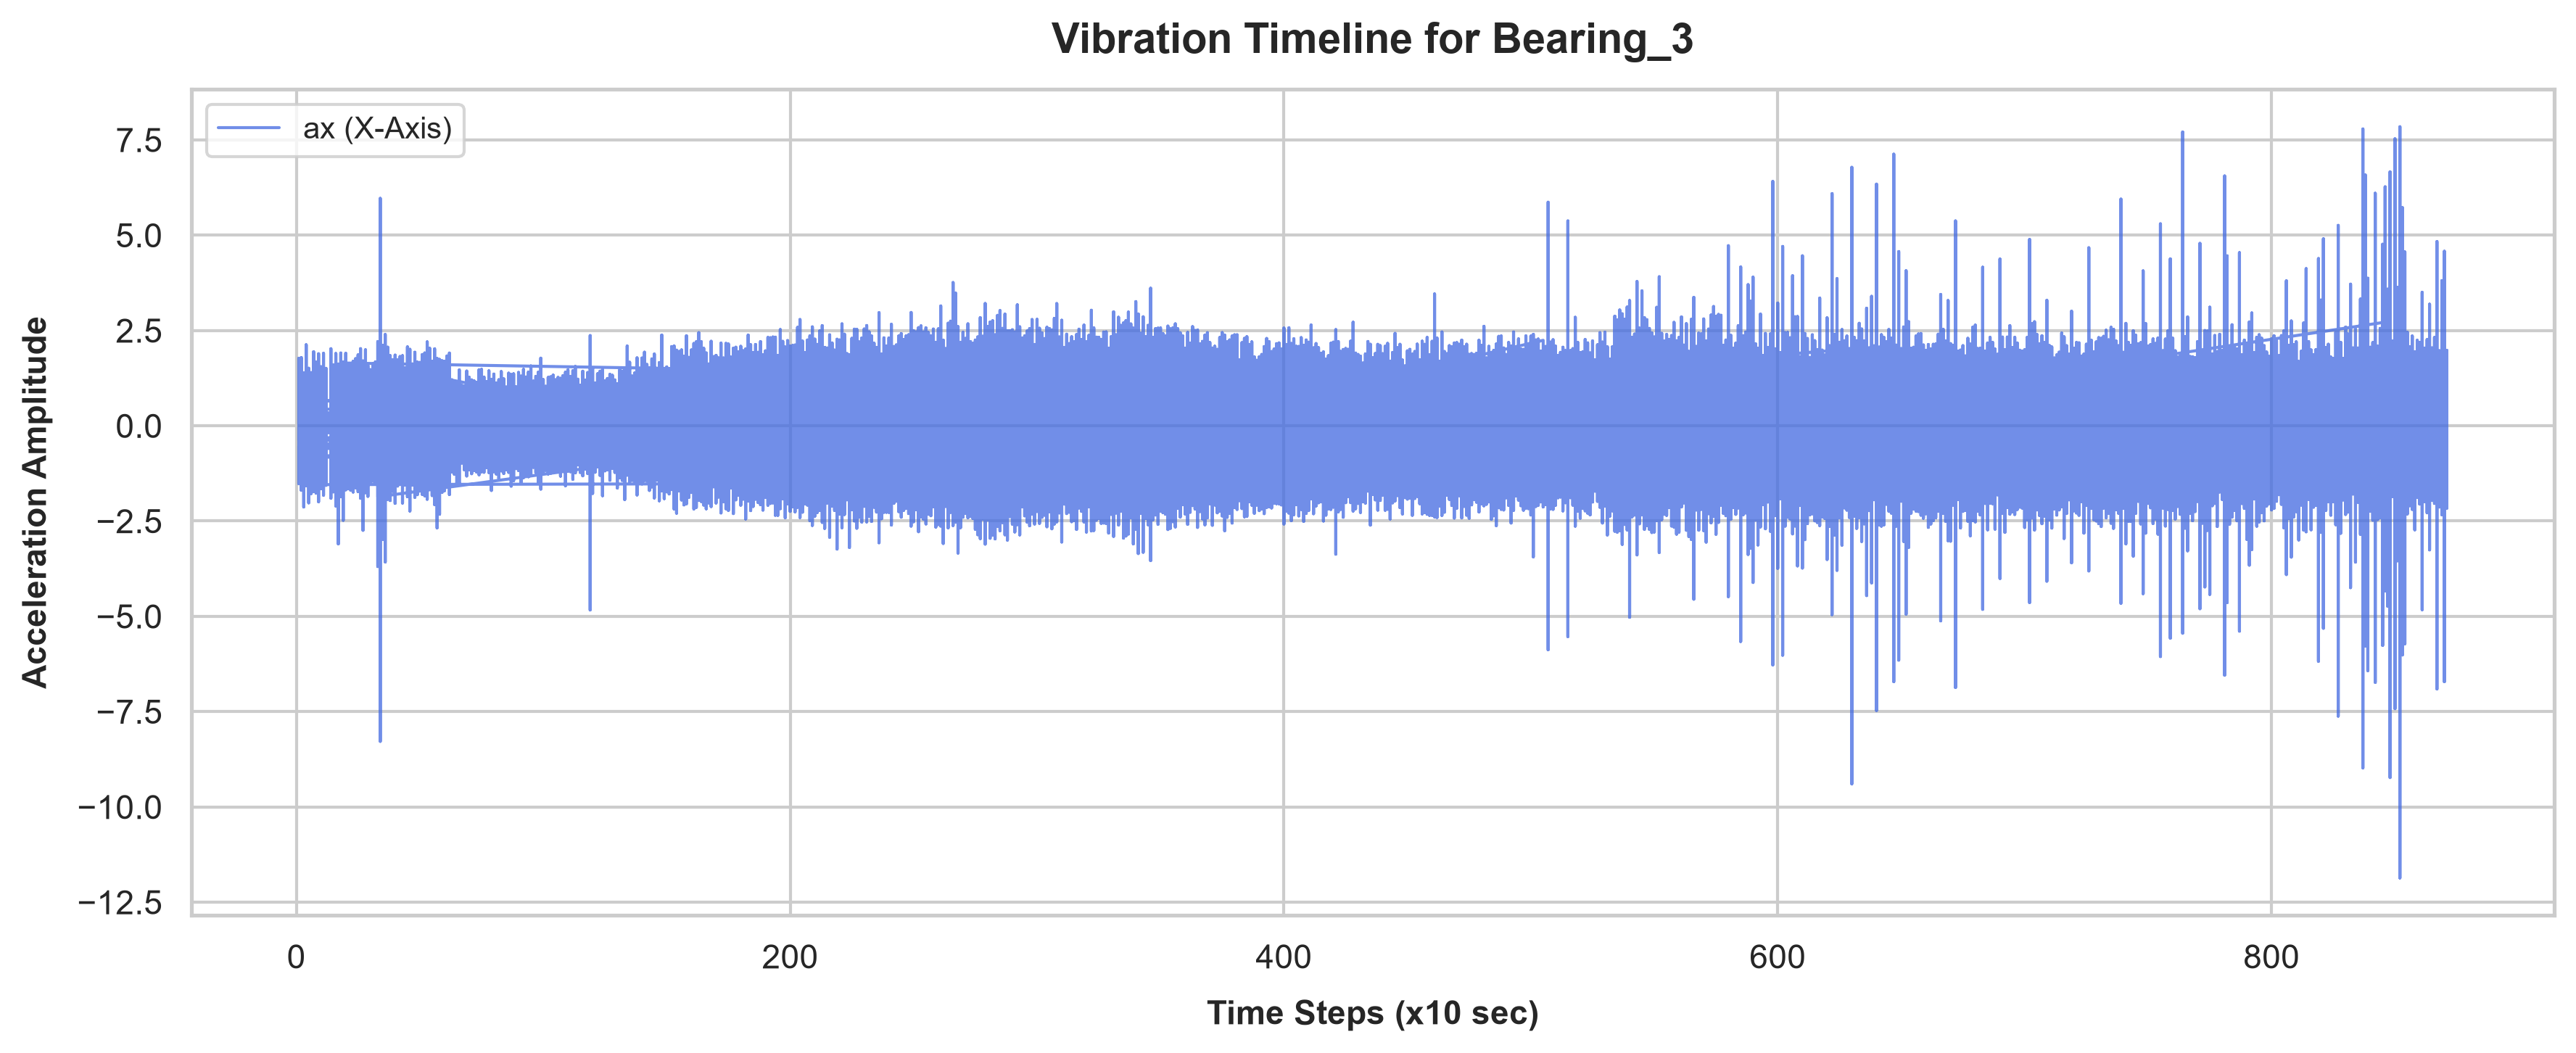

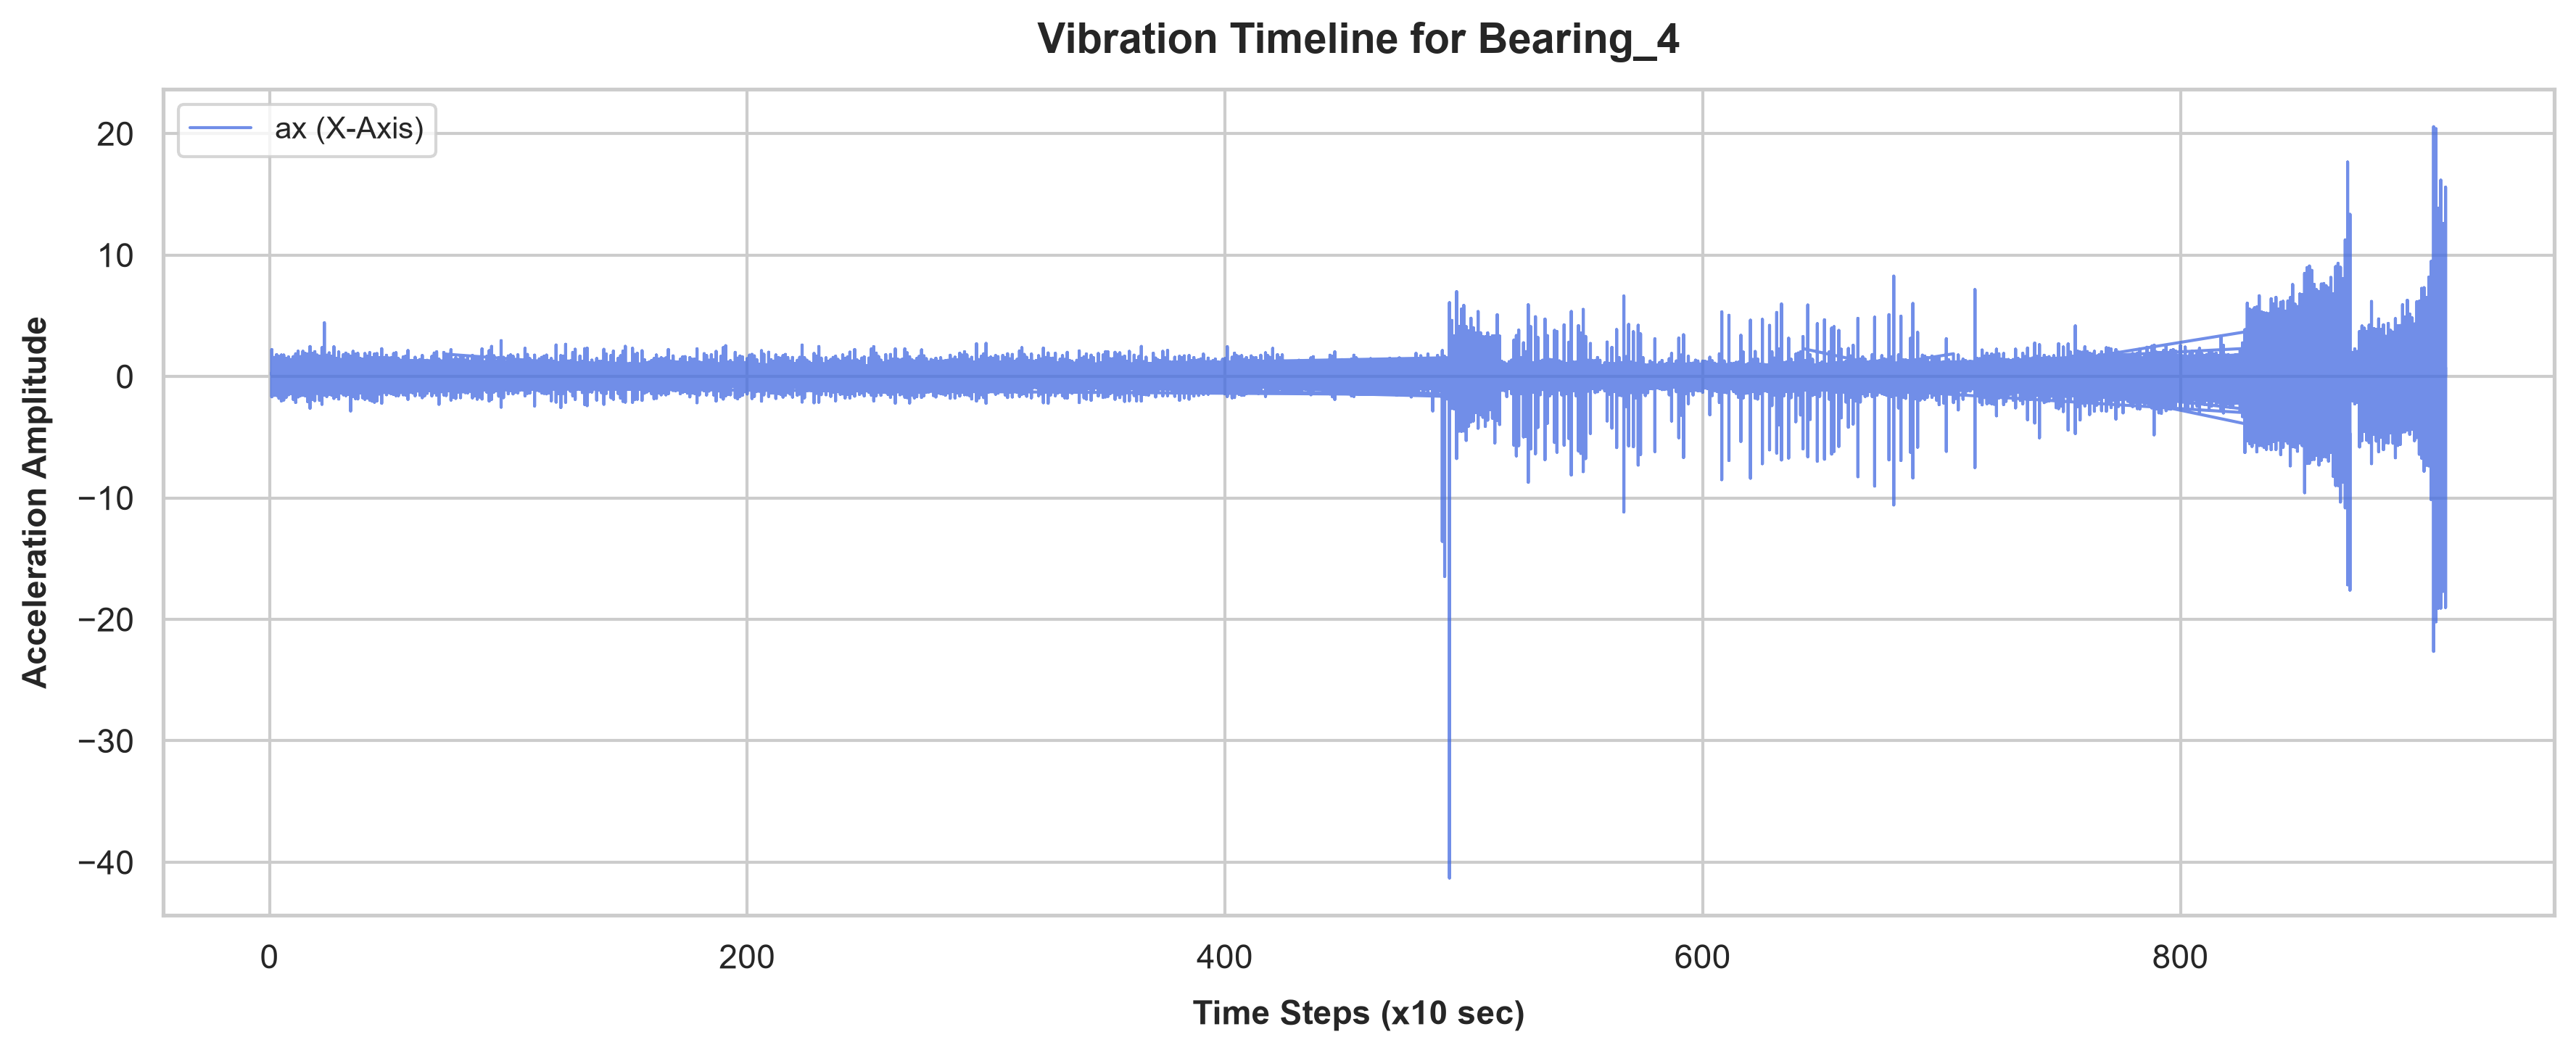

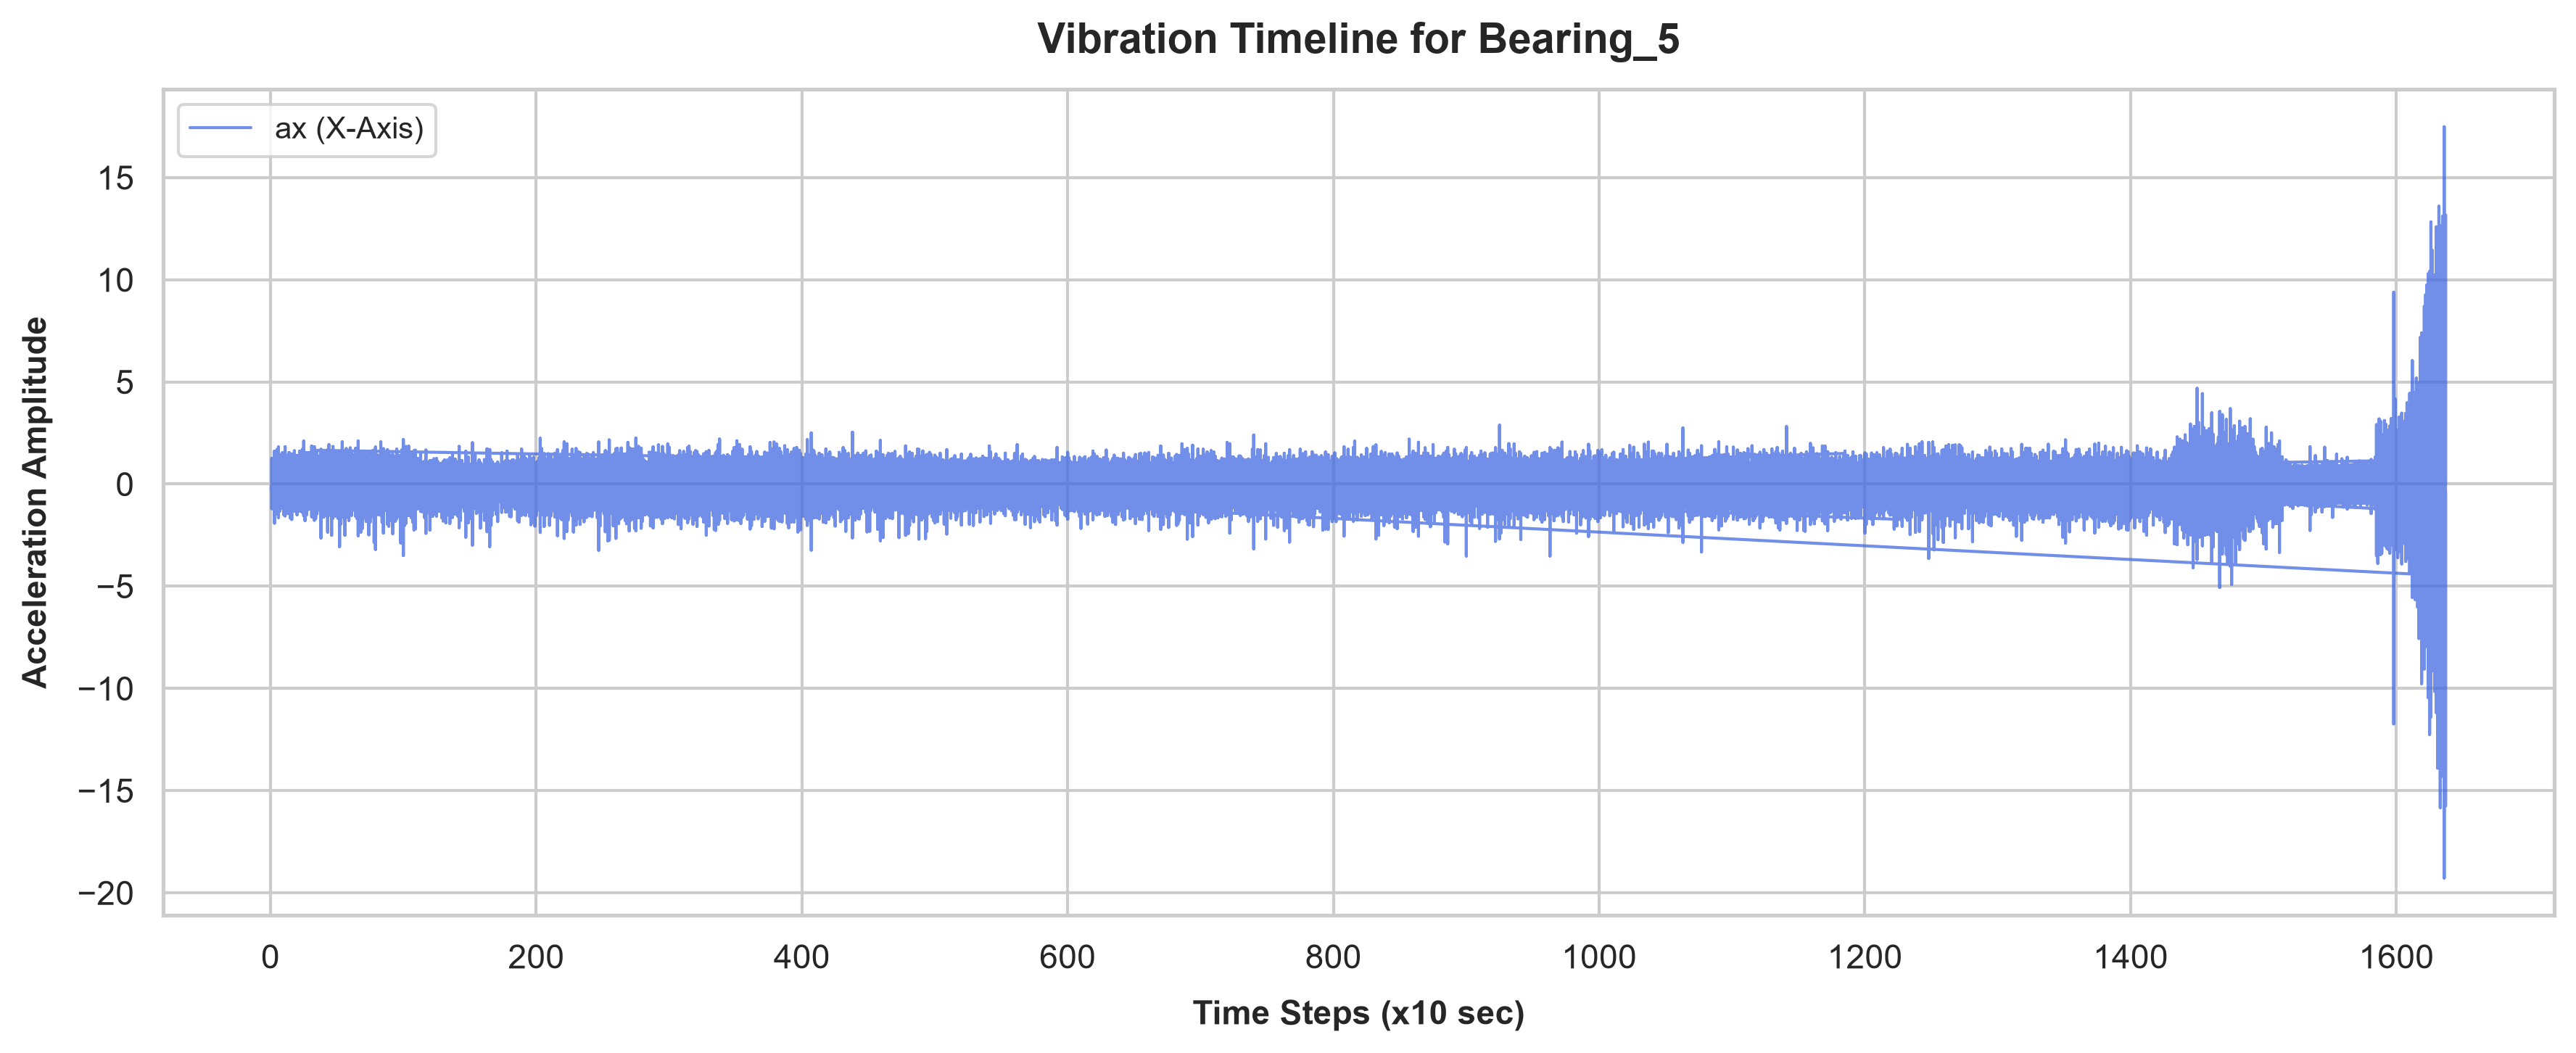

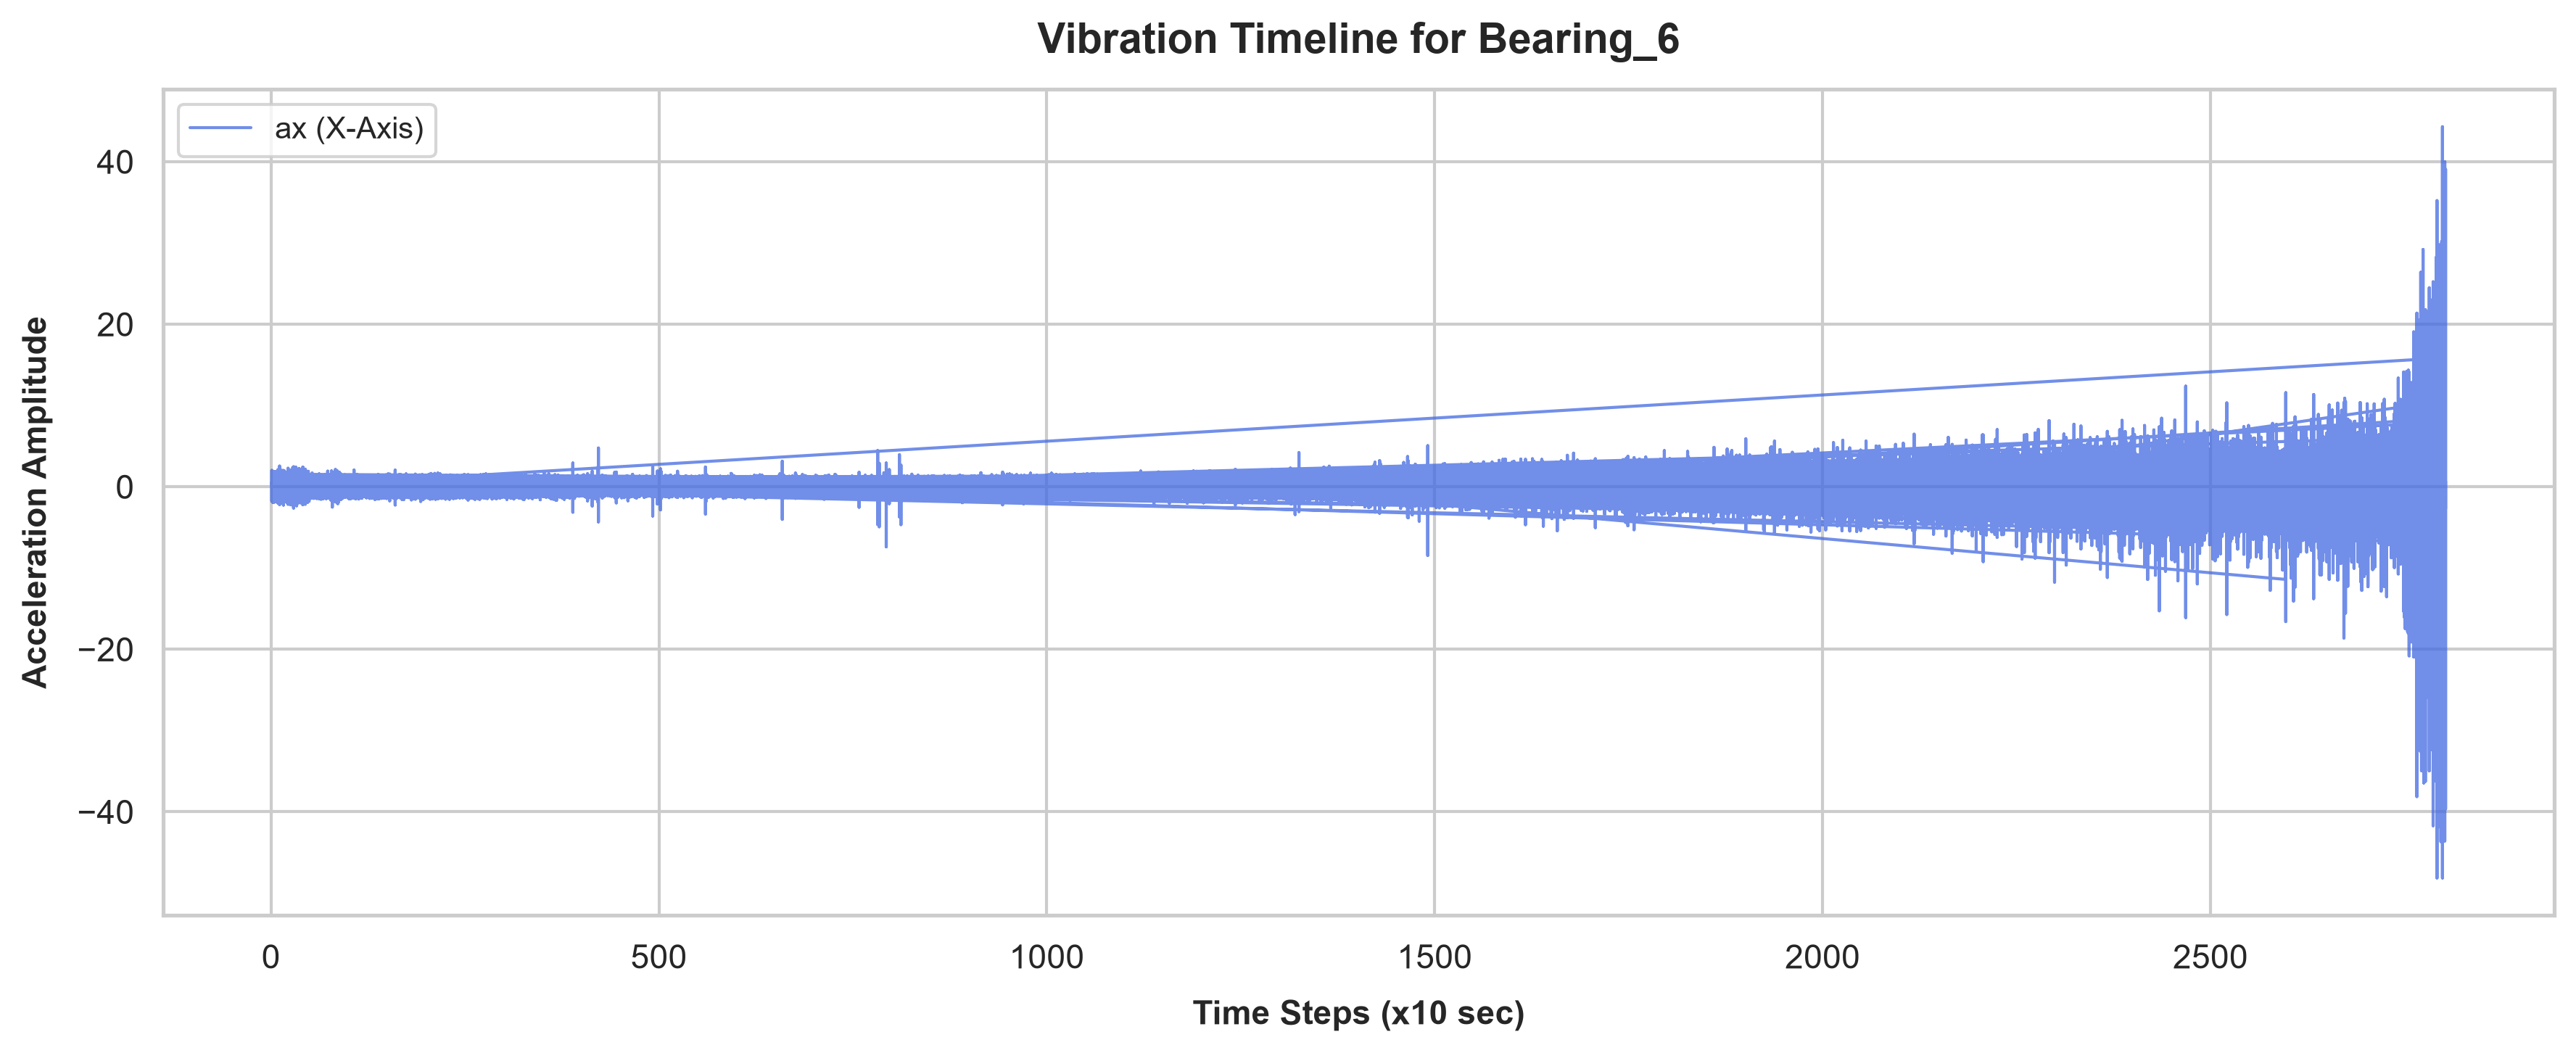

In [27]:
unique_bearings = sorted(processed_train_data['bearing_id'].unique())

# Iterate through each bearing and call the plotting function separately
for bearing in unique_bearings:
    # Filter dataset for the specific bearing
    bearing_df = processed_train_data[processed_train_data['bearing_id'] == bearing]
    
    # Call the function to render an individual plot for this bearing
    draw_plots_each_bearing_ax(bearing, bearing_df)
    

In [28]:

def draw_plots_each_bearing_ay(bearing_id: str, bearing_data: pd.DataFrame):
    """
    Creates a separate, publication-ready plot for a single bearing,
    displaying both Y (ay) axis vibrations on the same graph.
    """
    # Set the aesthetic style
    sns.set_theme(style="whitegrid")
    
    # Create an independent figure for the current bearing
    plt.figure(figsize=(12, 5), dpi=300)
    
    # Plot and Y-axis (ay) signals
    plt.plot(
        bearing_data['step'], 
        bearing_data['ay'], 
        color="orange", 
        linewidth=1.0, 
        alpha=0.75, 
        label='ay (Y-Axis)'
    )
    
    # Configure graph styling, titles, and labels
    plt.title(f'Vibration Timeline for {bearing_id.capitalize()}', fontsize=14, fontweight='bold', pad=12)
    plt.xlabel('Time Steps (x10 sec)', fontsize=11, fontweight='bold', labelpad=8)
    plt.ylabel('Acceleration Amplitude', fontsize=11, fontweight='bold', labelpad=8)
    
    # Add legend and layout adjustments
    plt.legend(frameon=True, facecolor='white', loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()



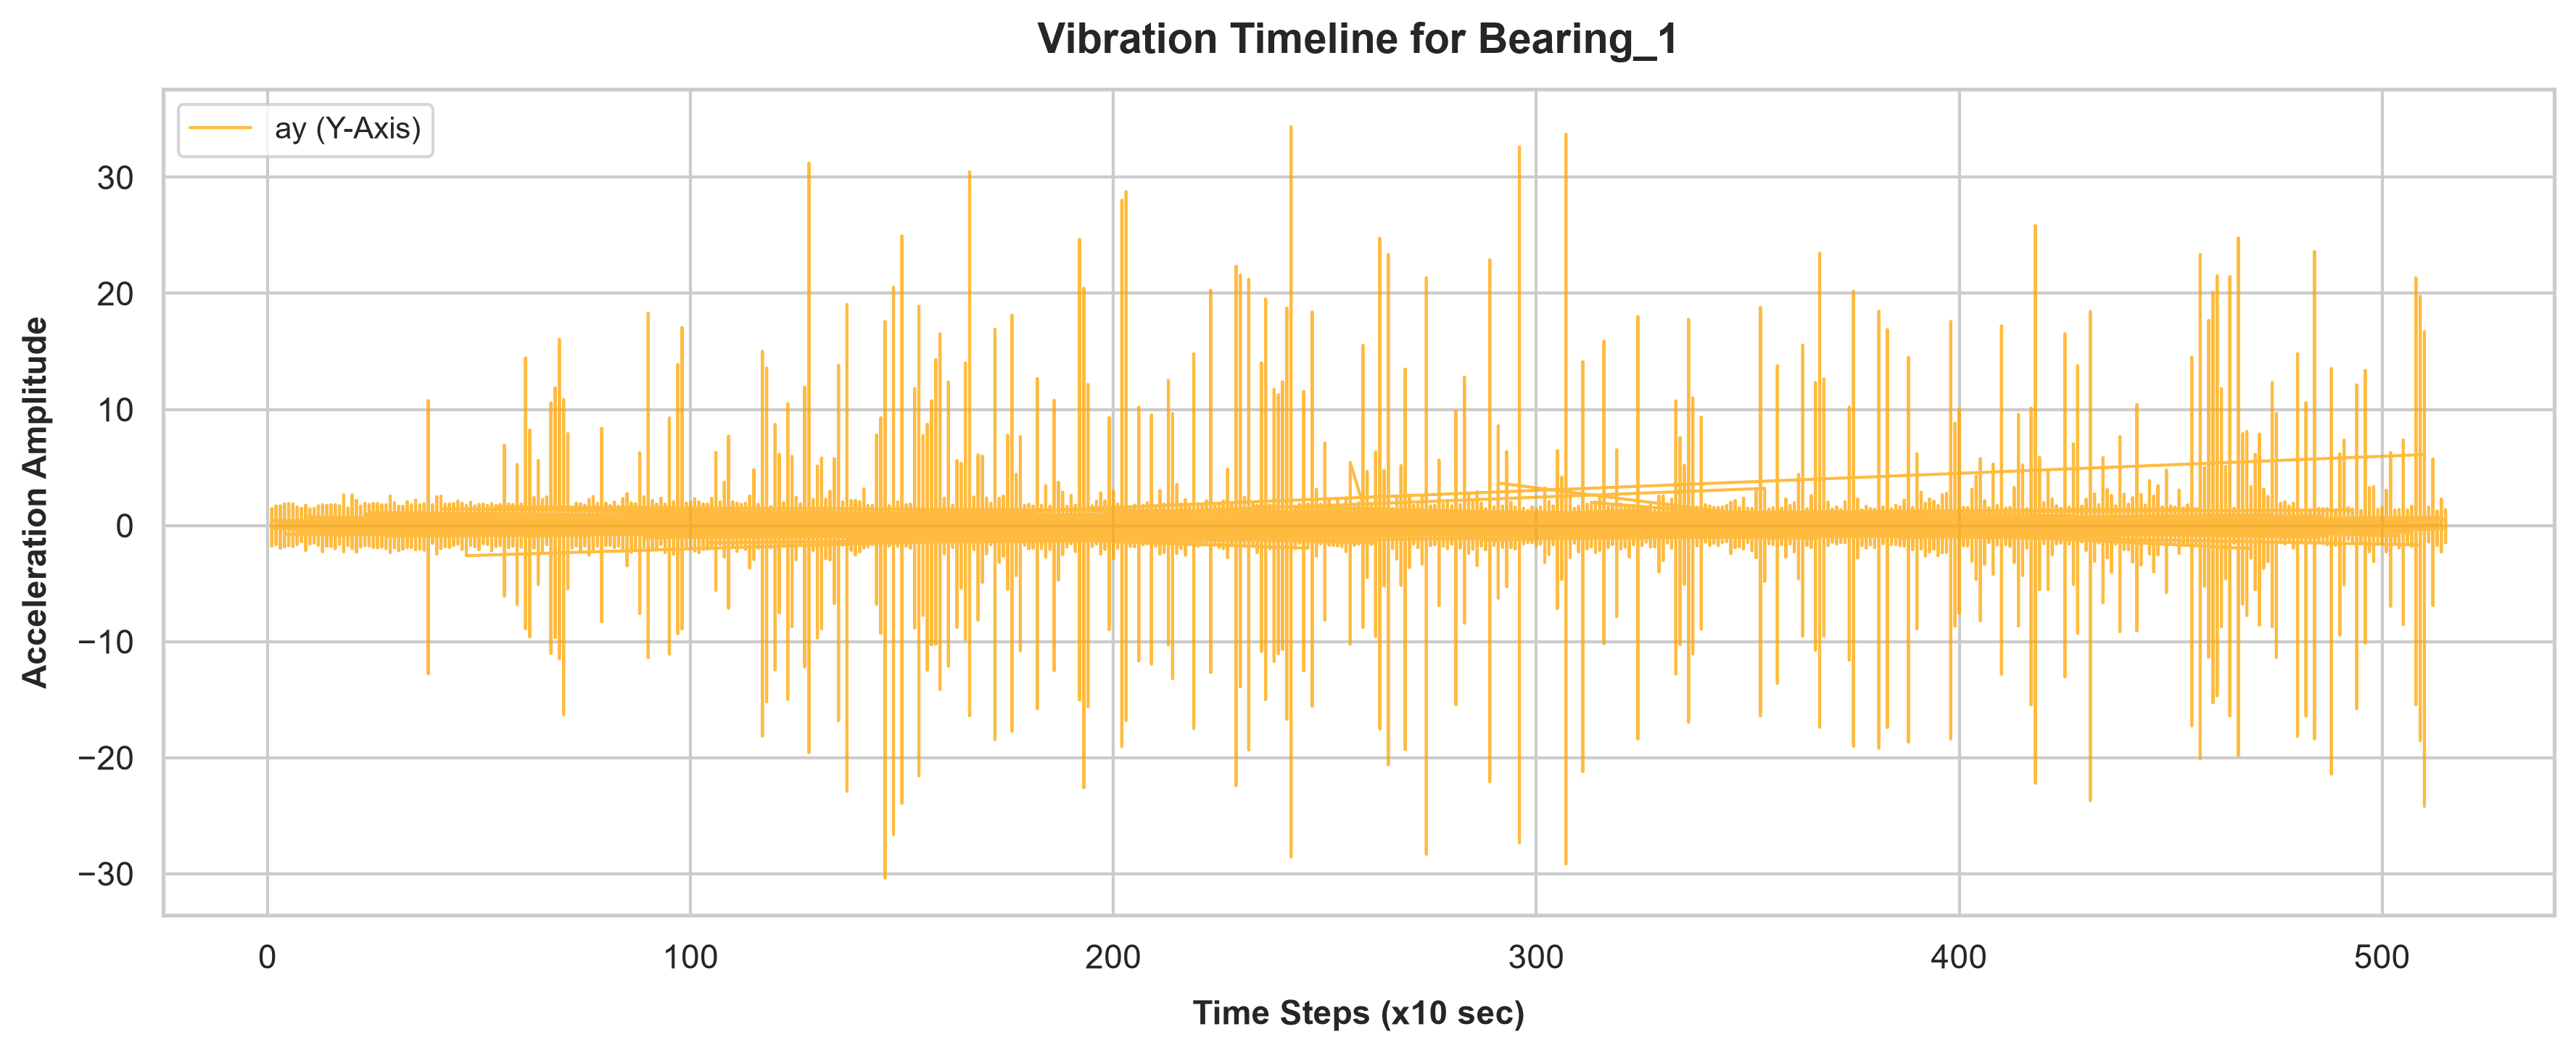

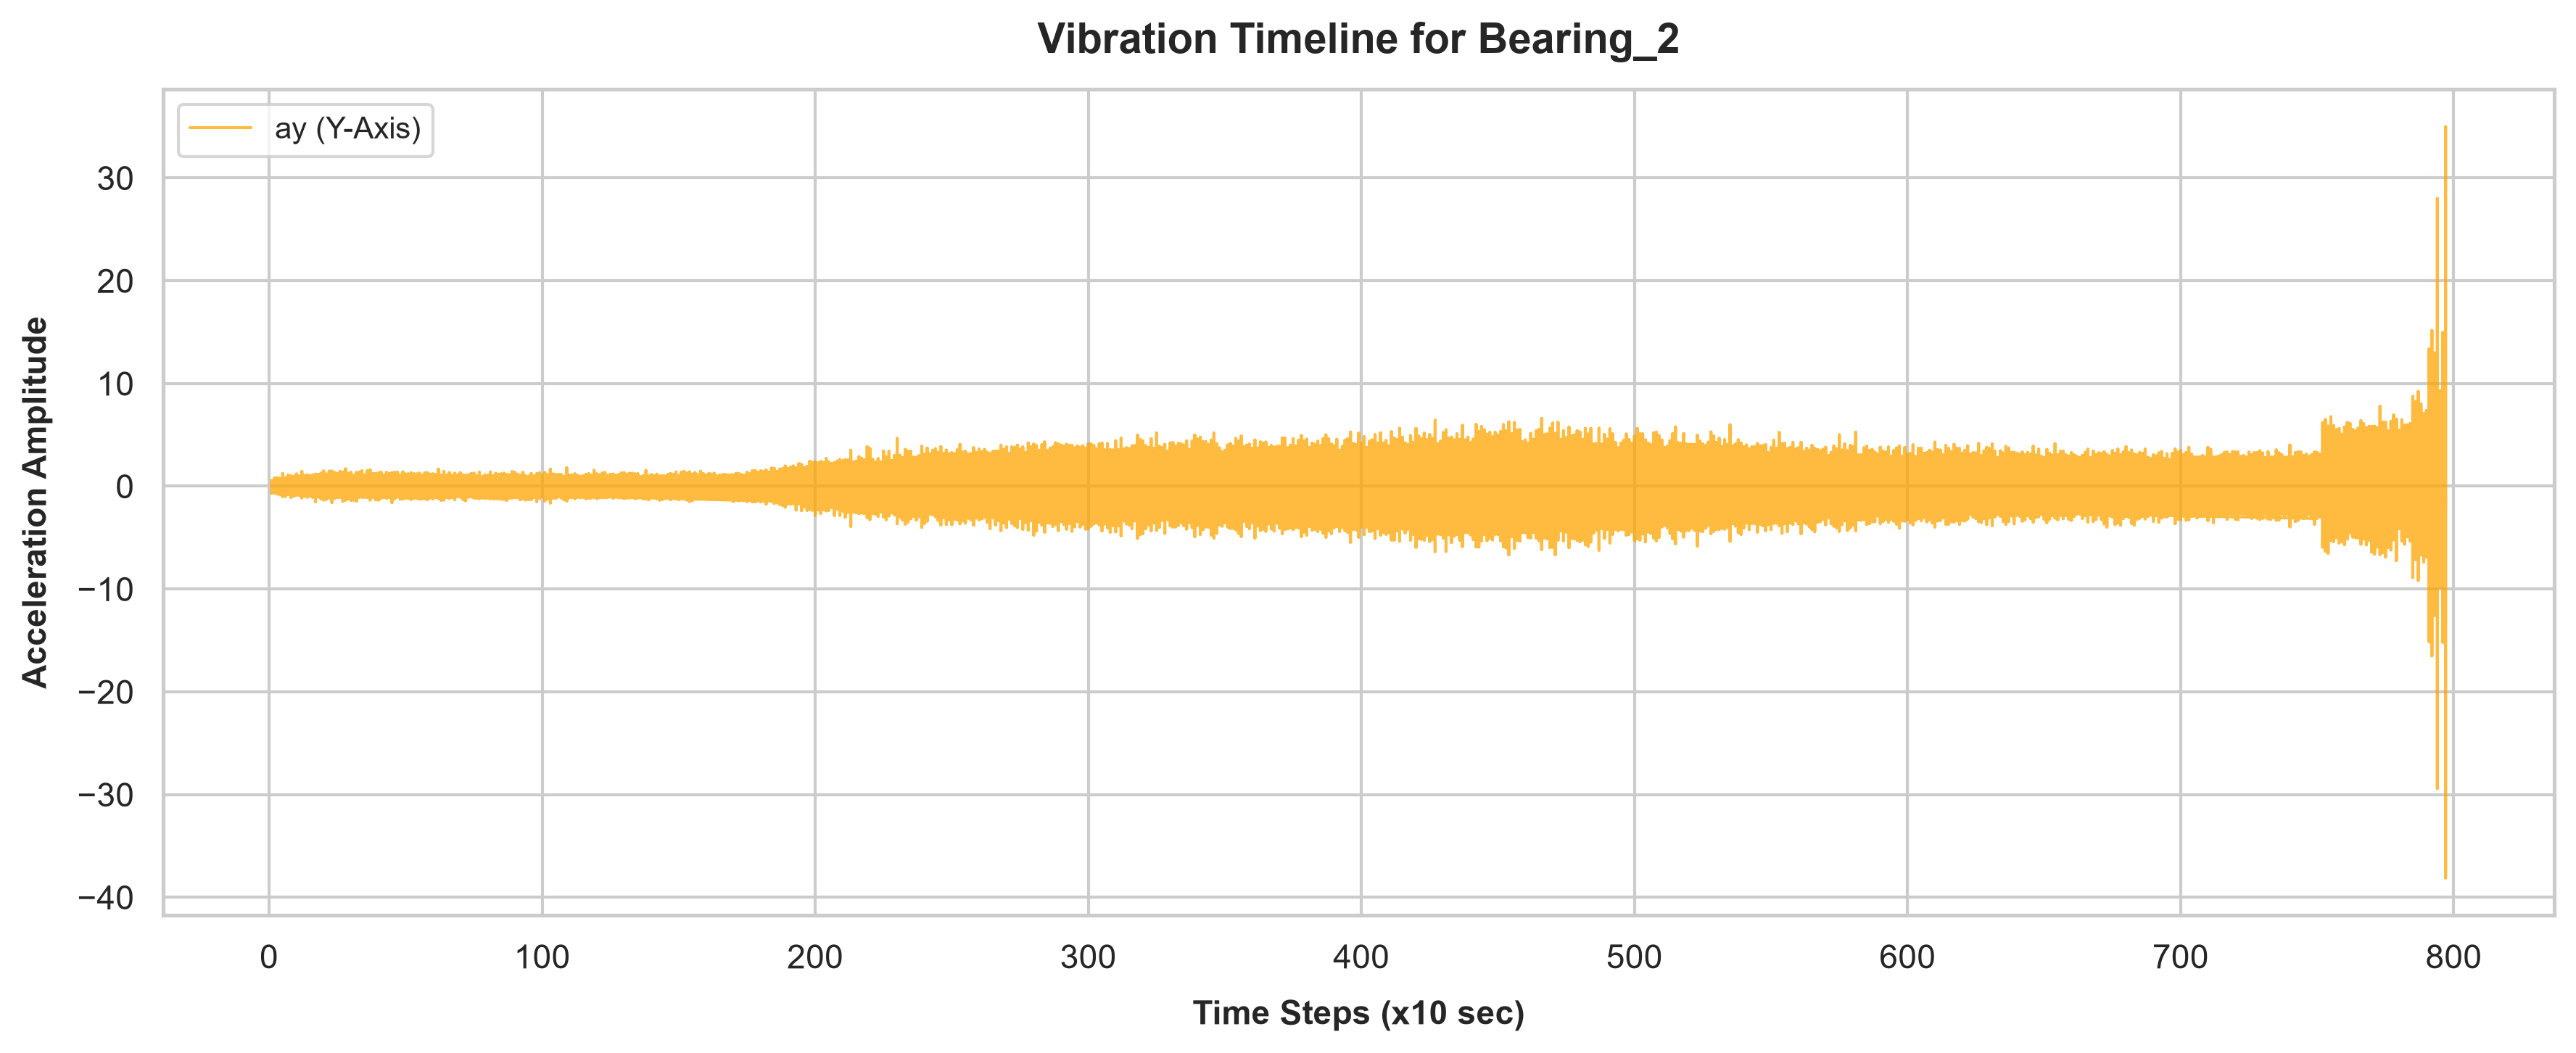

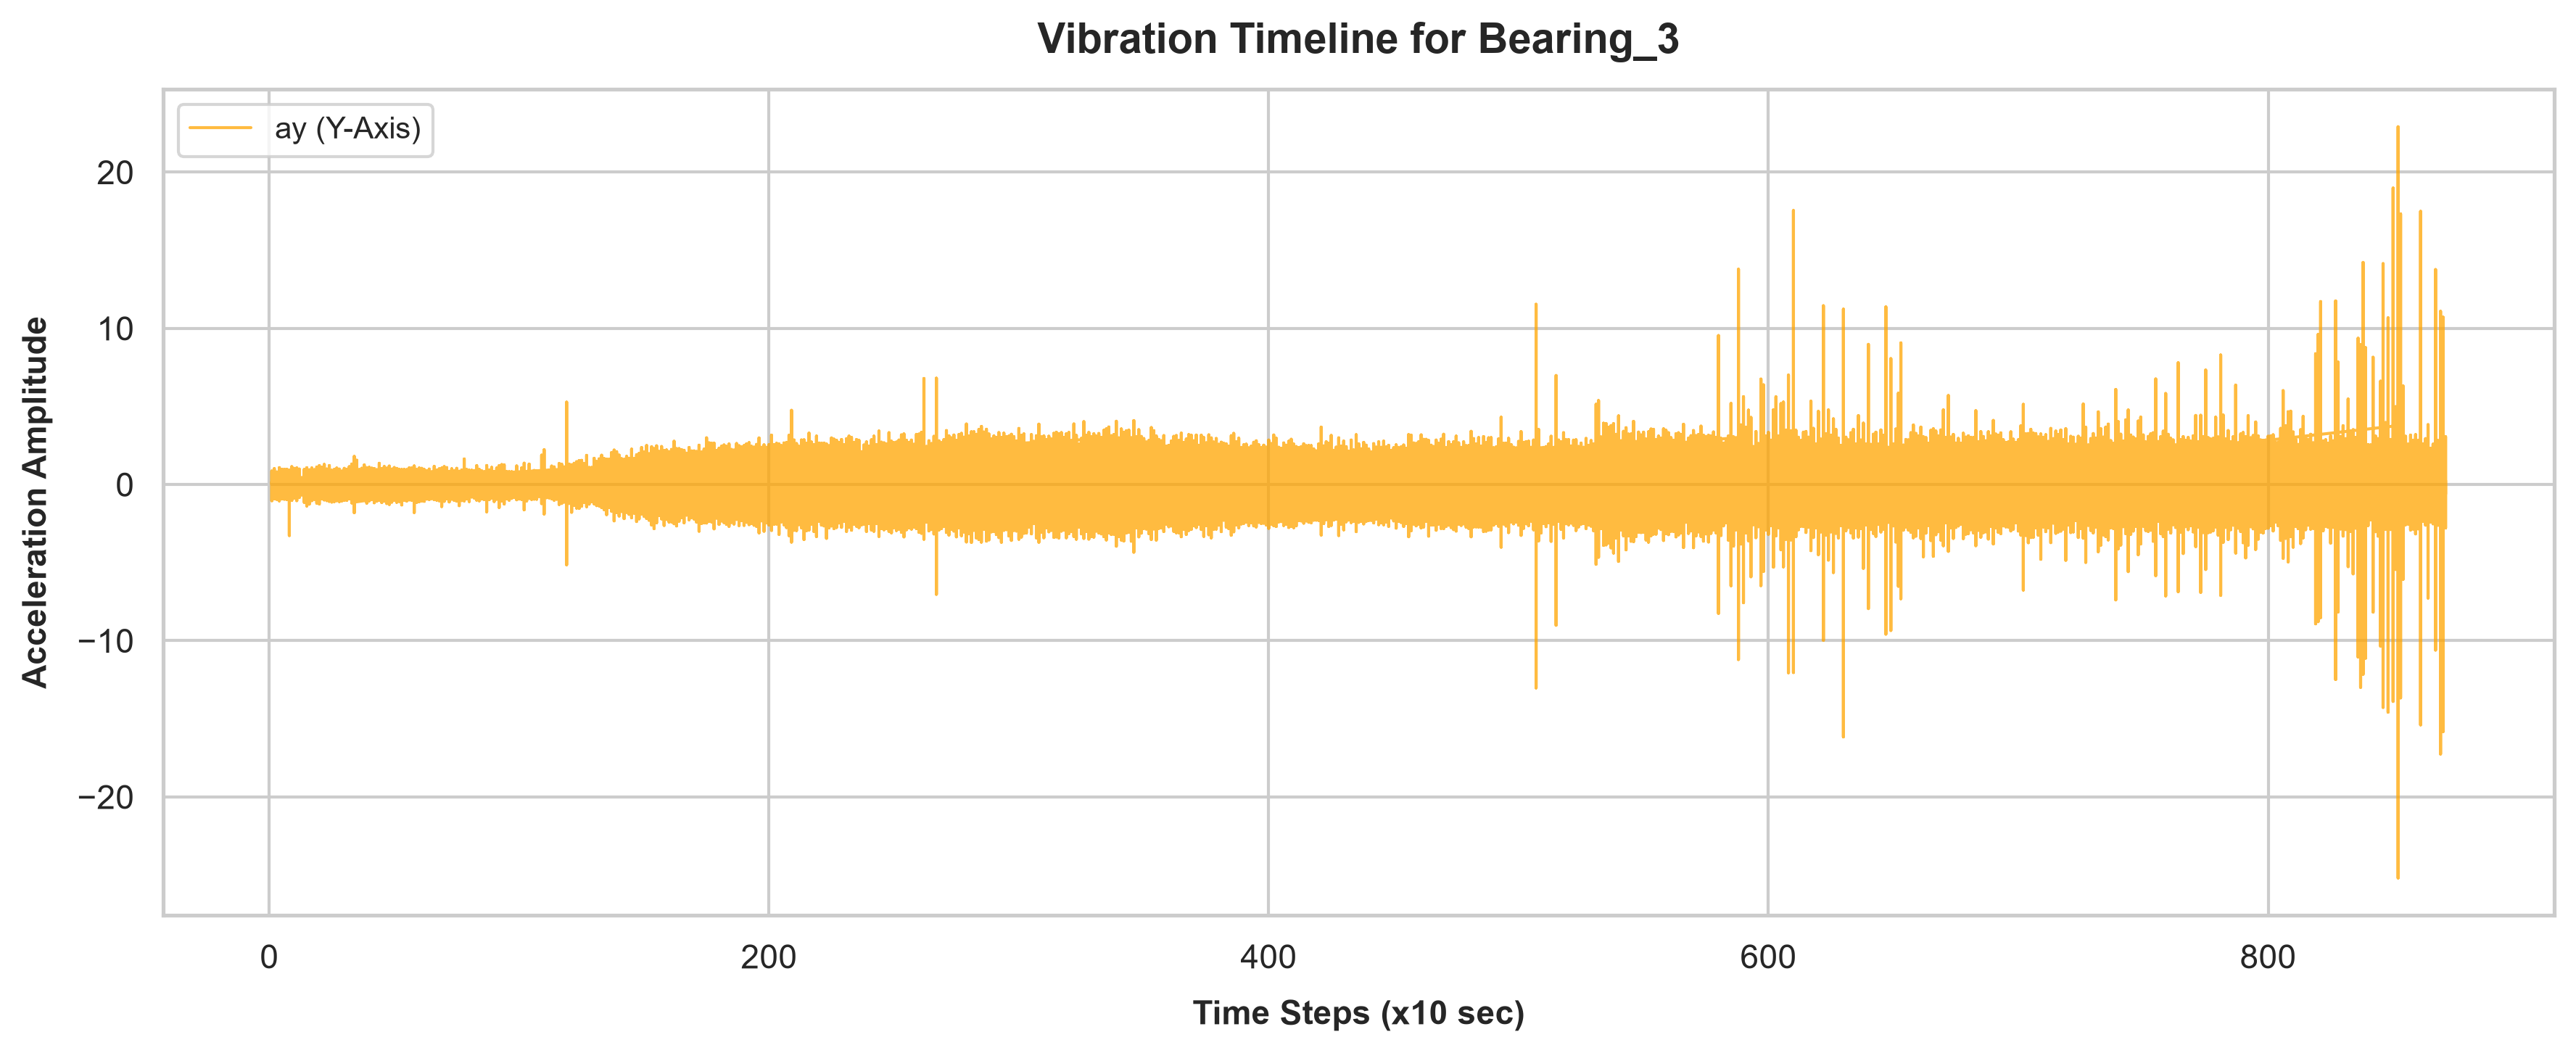

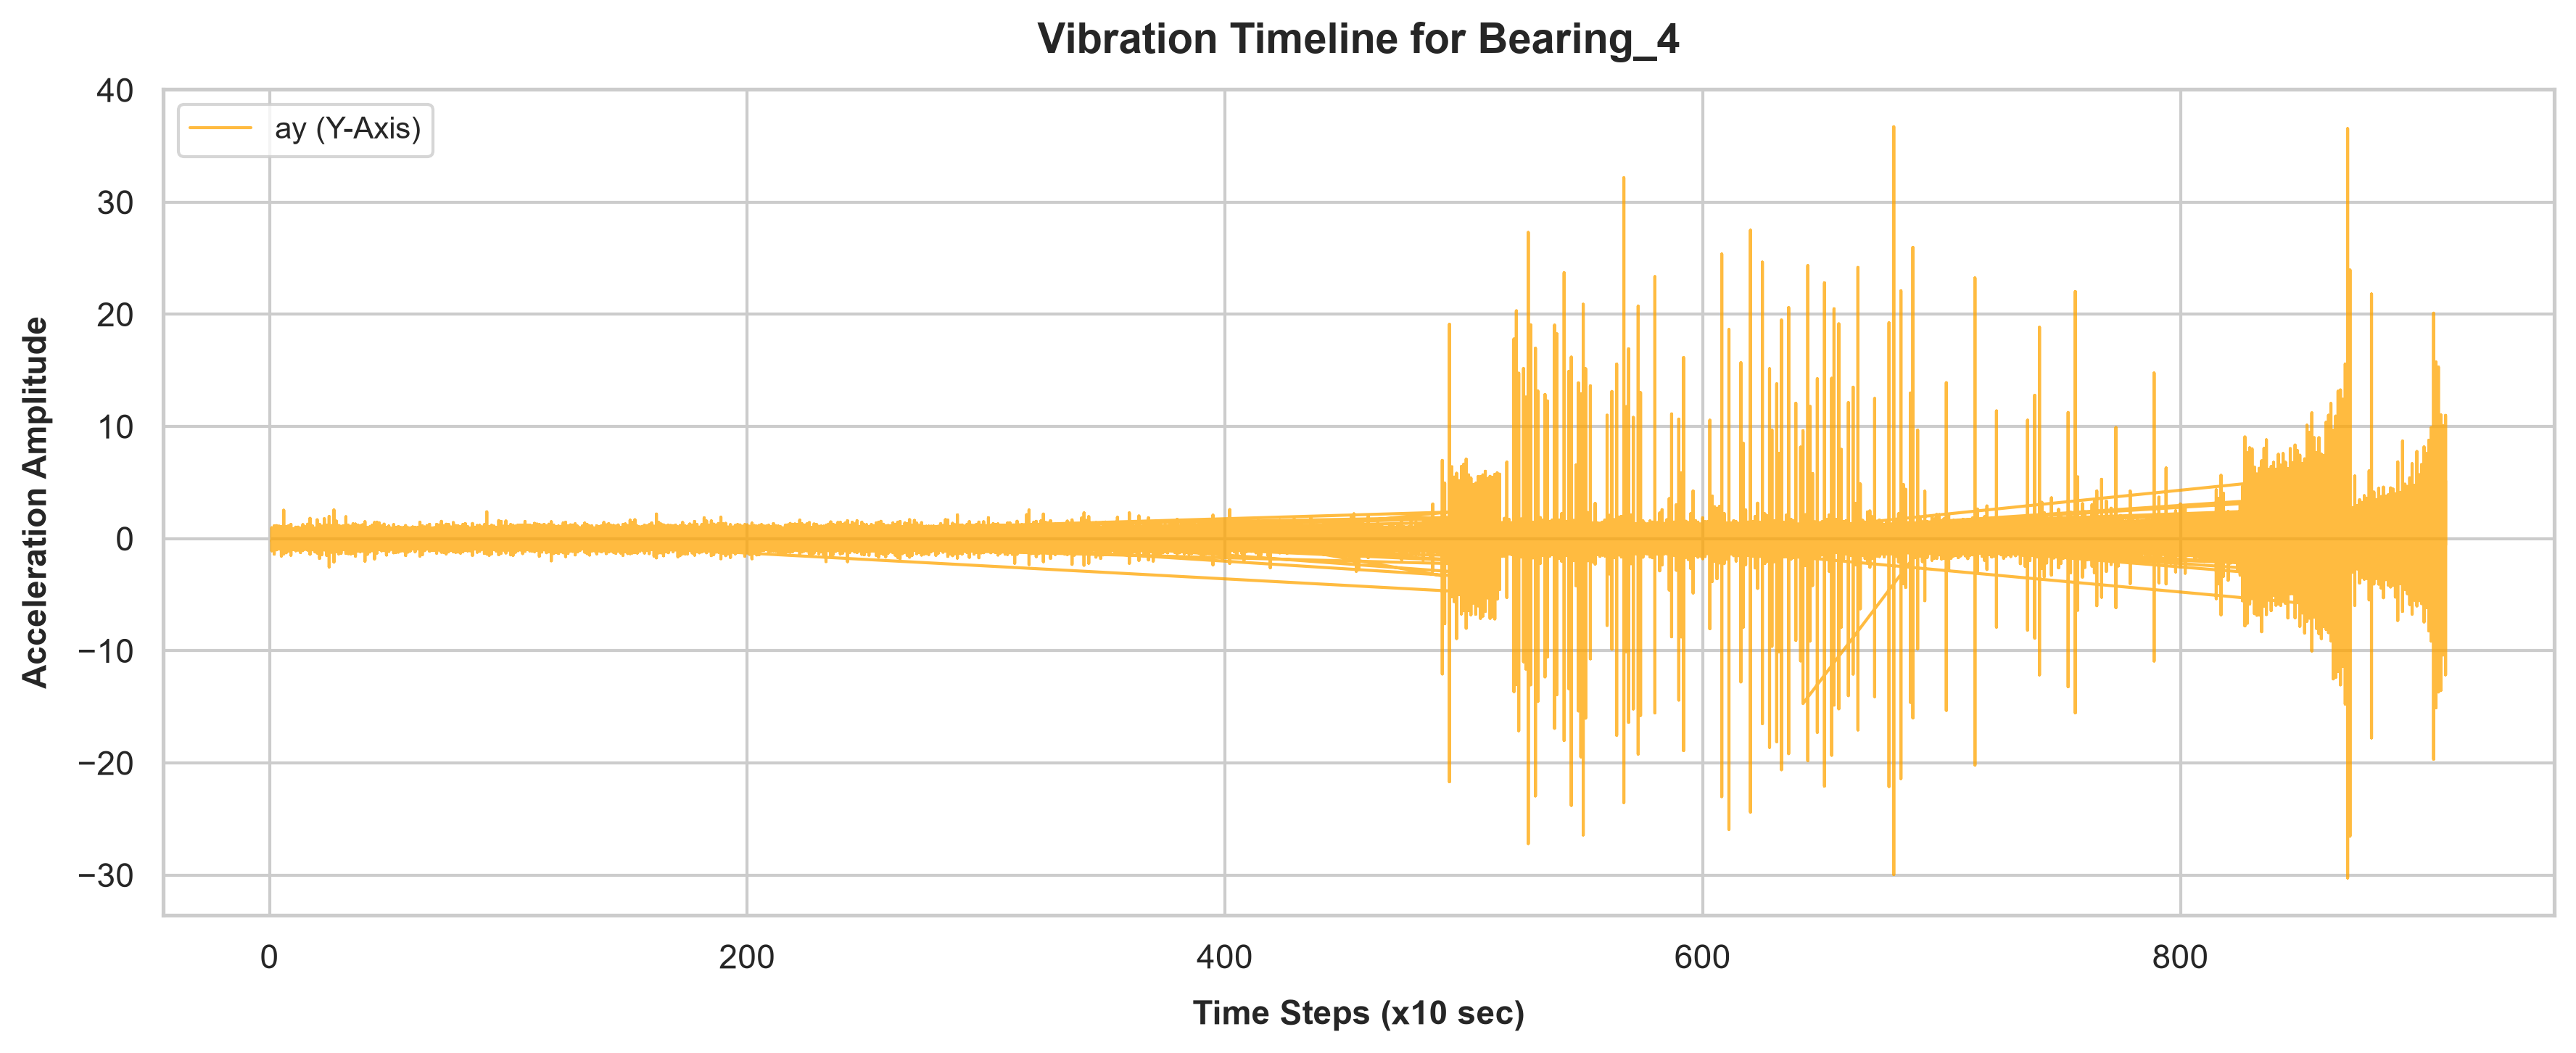

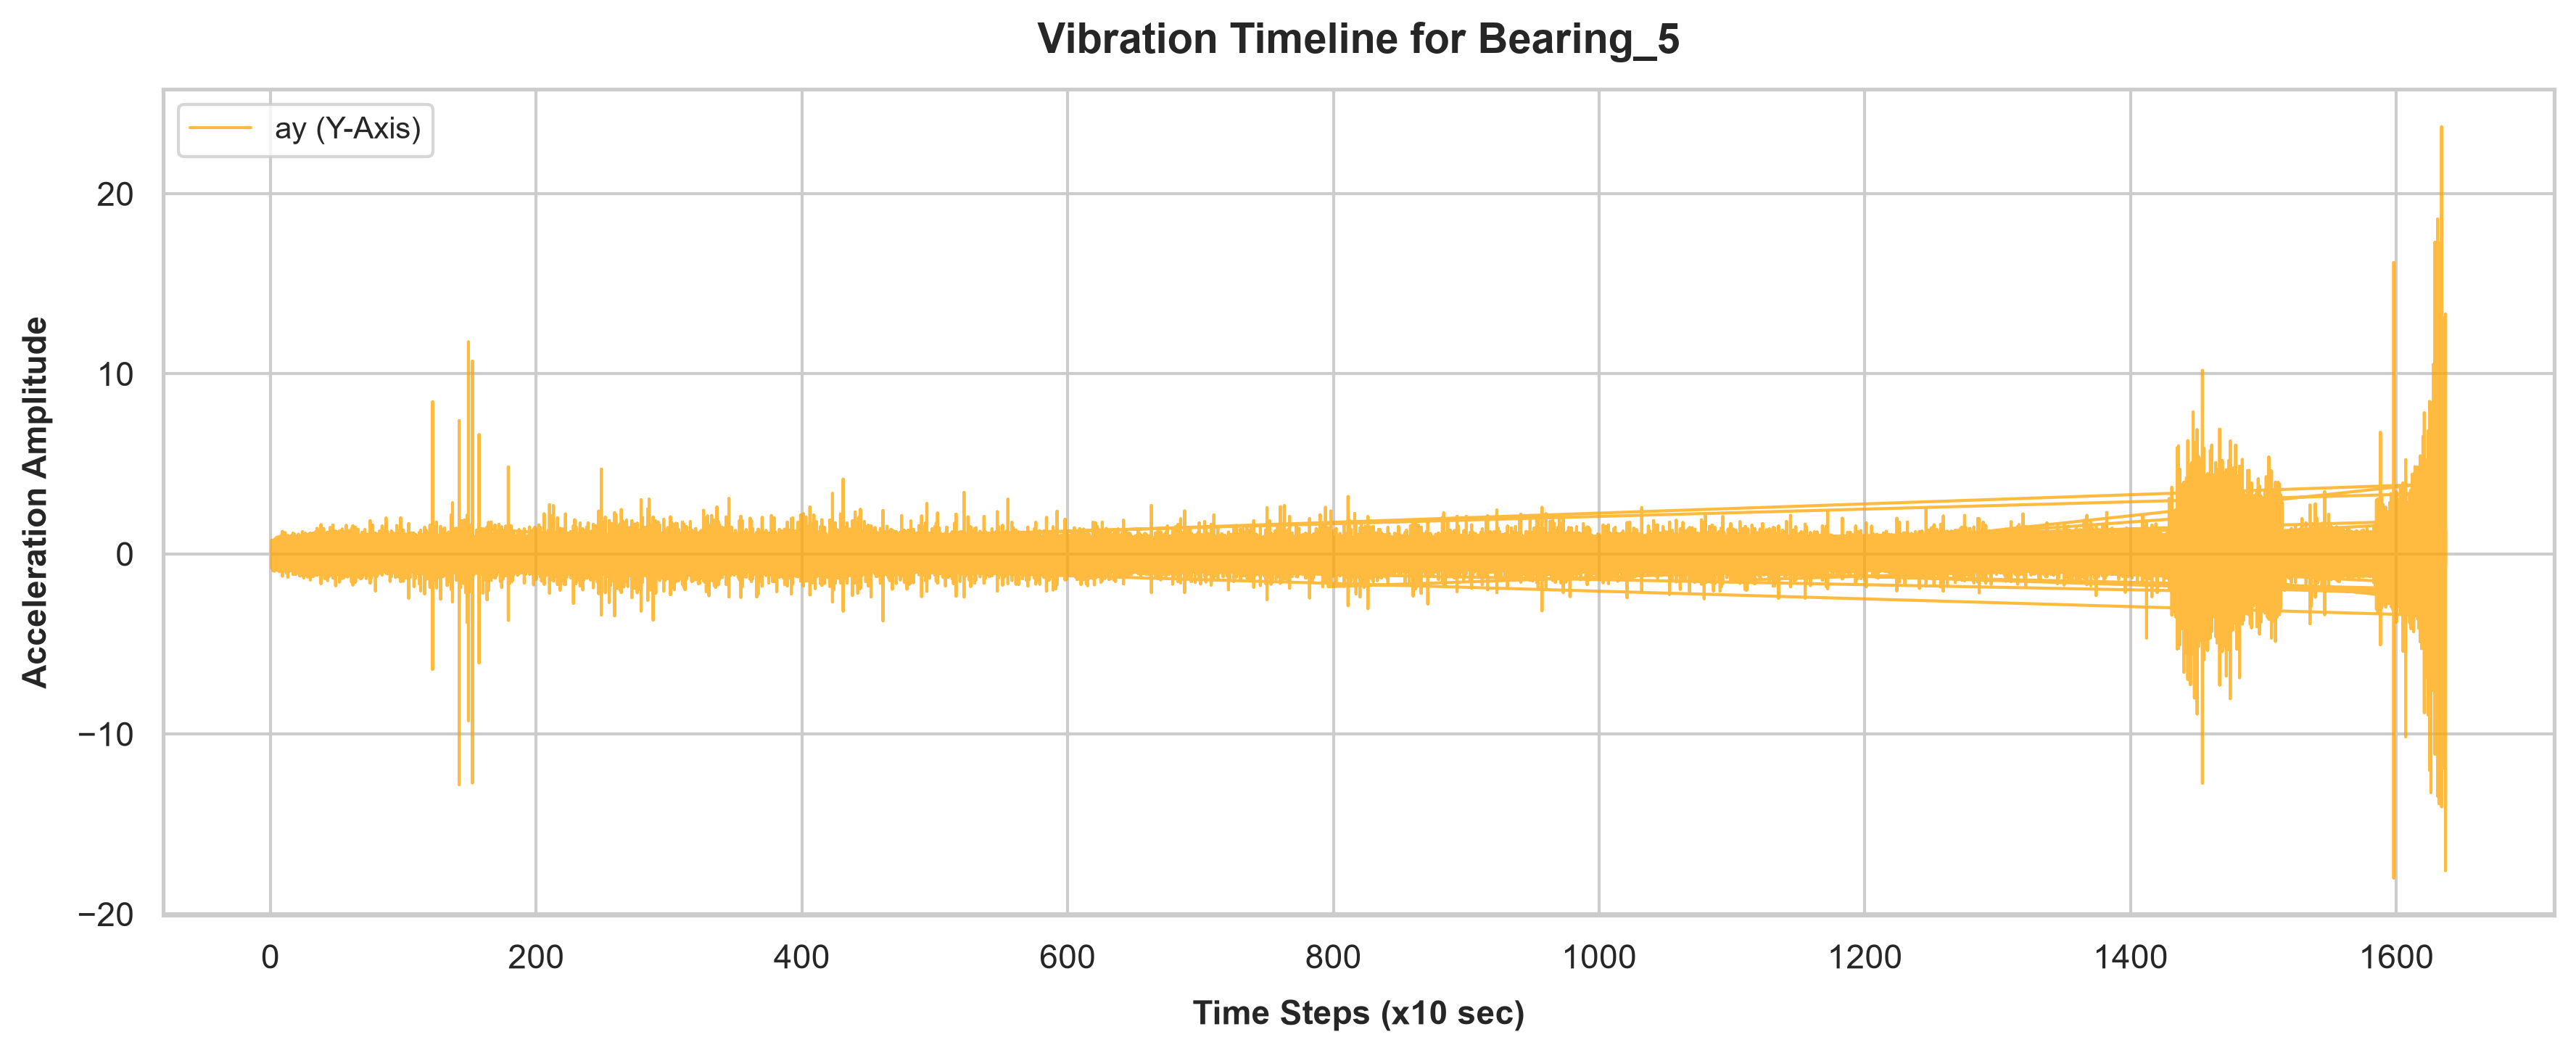

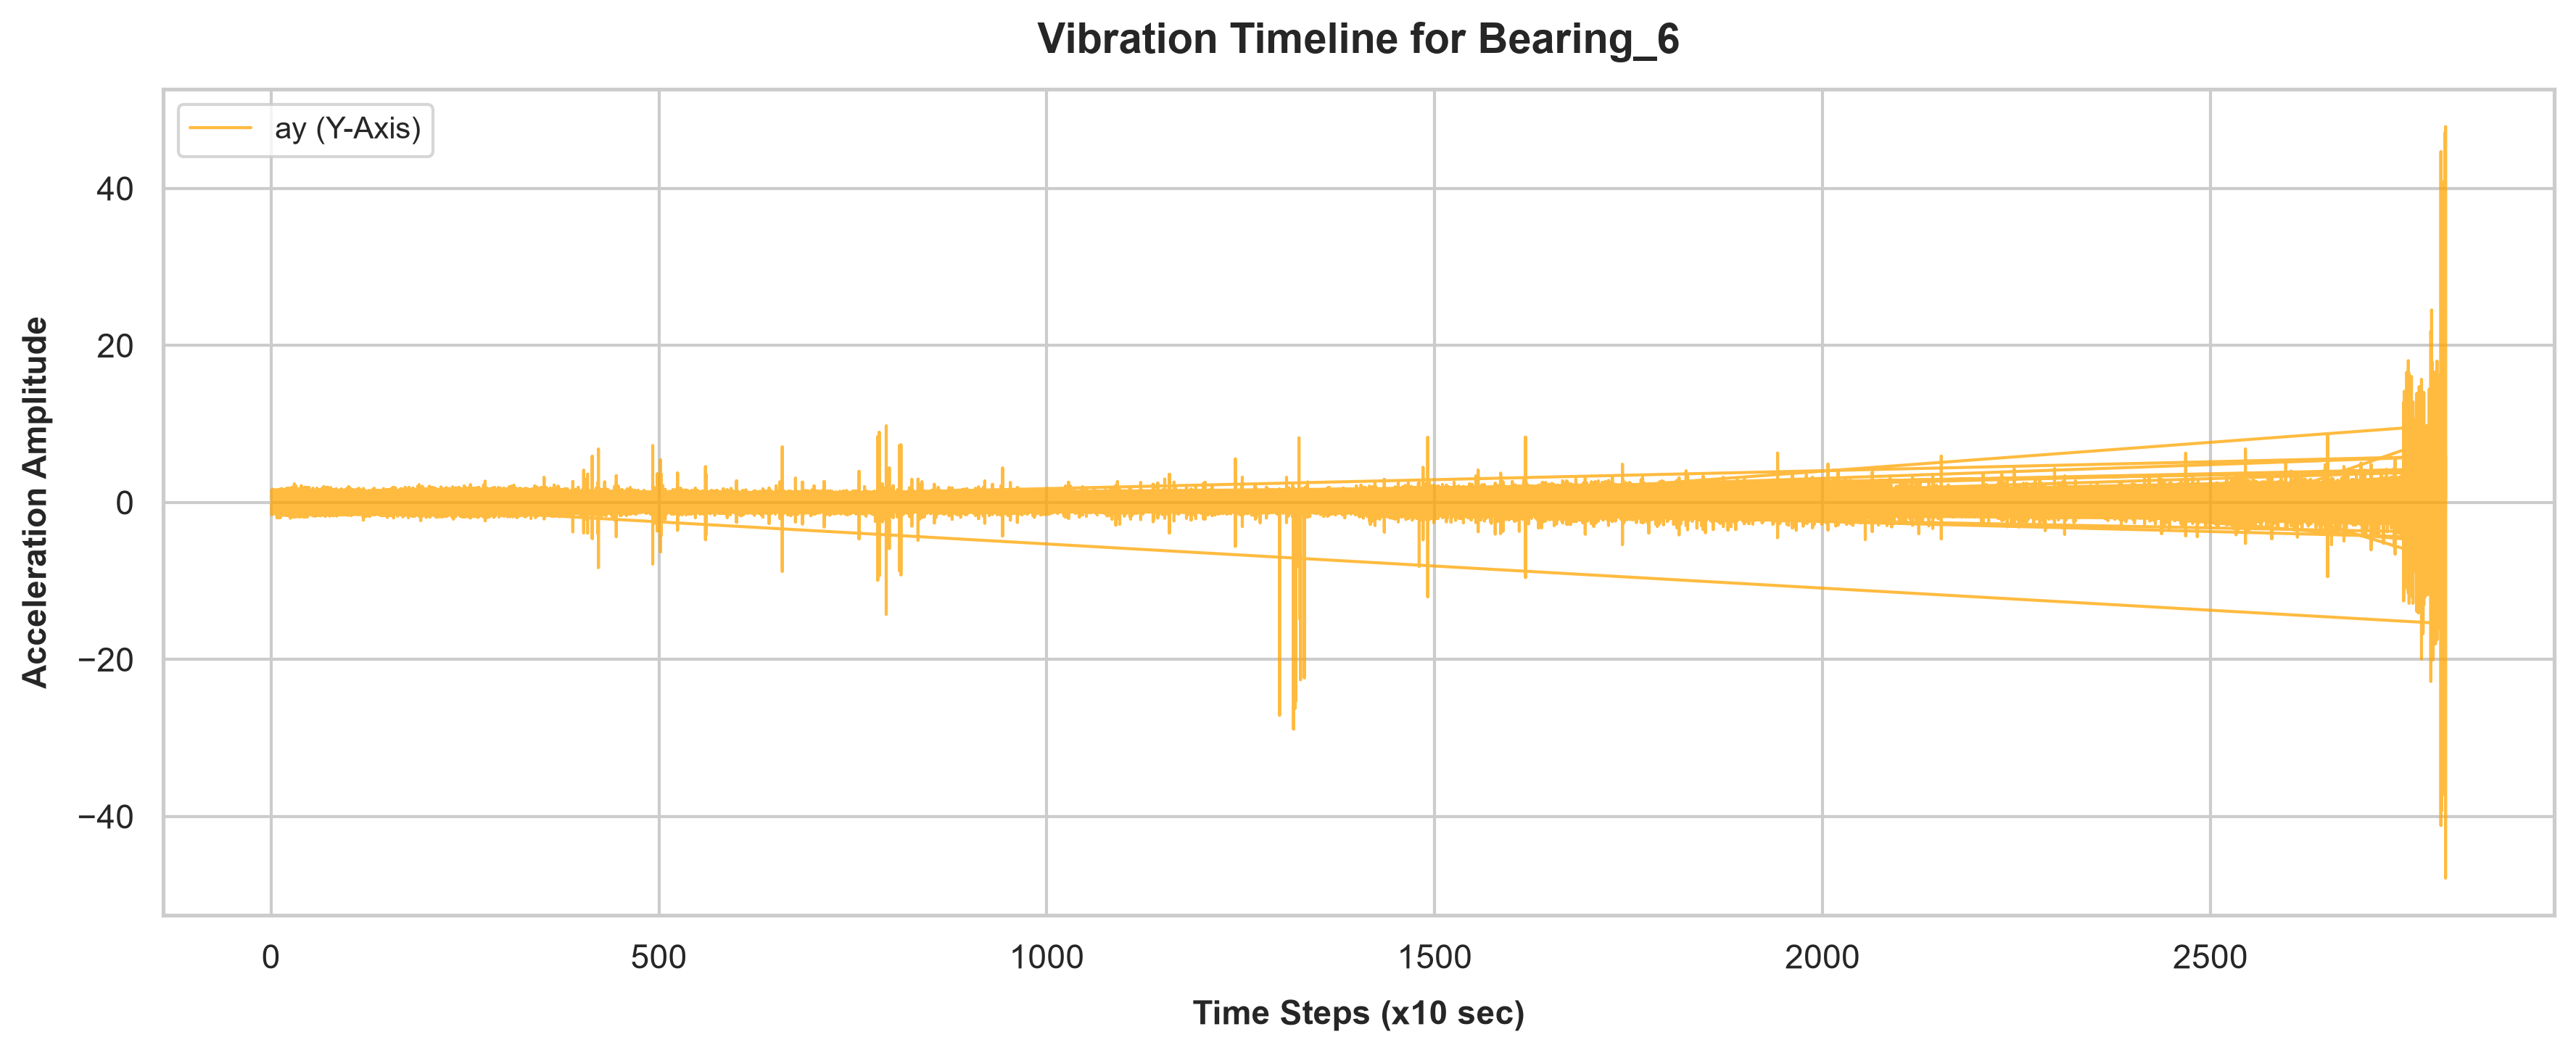

In [29]:

for bearing in unique_bearings:
    # Filter dataset for the specific bearing
    bearing_df = processed_train_data[processed_train_data['bearing_id'] == bearing]
    
    # Call the function to render an individual plot for this bearing
    draw_plots_each_bearing_ay(bearing, bearing_df)
    

In [30]:
print(processed_train_data['bearing_id'].unique())

<ArrowStringArray>
['bearing_6', 'bearing_3', 'bearing_4', 'bearing_2', 'bearing_1', 'bearing_5']
Length: 6, dtype: str


In [31]:
processed_train_data

,ax,ay,mag,ax_diff,ay_diff,mag_diff,source_file,step,row_in_file,block_idx,bearing_id
0,-0.176,-0.199,0.265663,0.000,0.000,0.000000,acc_01192.csv,1192,0,0,bearing_6
1,-0.038,-0.030,0.048415,0.138,0.169,-0.217248,acc_01192.csv,1192,1,0,bearing_6
2,-0.029,-0.261,0.262606,0.009,-0.231,0.214191,acc_01192.csv,1192,2,0,bearing_6
3,-0.169,0.271,0.319378,-0.140,0.532,0.056771,acc_01192.csv,1192,3,0,bearing_6
4,-0.241,0.612,0.657742,-0.072,0.341,0.338365,acc_01192.csv,1192,4,0,bearing_6
...,...,...,...,...,...,...,...,...,...,...,...
19287035,0.031,-0.148,0.151212,0.071,-0.330,-0.035132,acc_01180.csv,1180,5115,1,bearing_5
19287036,-0.087,-0.043,0.097046,-0.118,0.105,-0.054165,acc_01180.csv,1180,5116,1,bearing_5
19287037,0.085,0.283,0.295489,0.172,0.326,0.198443,acc_01180.csv,1180,5117,1,bearing_5
19287038,0.095,-0.263,0.279632,0.010,-0.546,-0.015858,acc_01180.csv,1180,5118,1,bearing_5


In [ ]:
def extract_features(group):
    return pd.Series({
        'mean_ax': group['ax'].mean(),
        'rms_ax': np.sqrt(np.mean(group['ax']**2)),
        'std_ax': group['ax'].std(),
        'skew_ax': group['ax'].skew(),
        'kurtosis_ax': group['ax'].kurtosis(),
        'peak_ax': group['ax'].max(),
        'p2p_ax': group['ax'].max() - group['ax'].min(),
        'crest_ax': group['ax'].max() / np.sqrt(np.mean(group['ax']**2)),

        'mean_ay': group['ay'].mean(),
        'rms_ay': np.sqrt(np.mean(group['ay']**2)),
        'std_ay': group['ay'].std(),
        'skew_ay': group['ay'].skew(),
        'kurtosis_ay': group['ay'].kurtosis(),
        'peak_ay': group['ay'].max(),
        'p2p_ay': group['ay'].max() - group['ay'].min(),
        'crest_ay': group['ay'].max() / np.sqrt(np.mean(group['ay']**2)),
    })

features_train_data = processed_train_data.groupby(['bearing_id', 'step']).apply(extract_features).reset_index()
features_train_data.head()

,bearing_id,step,mean_ax,rms_ax,std_ax,skew_ax,kurtosis_ax,peak_ax,p2p_ax,crest_ax,mean_ay,rms_ay,std_ay,skew_ay,kurtosis_ay,peak_ay,p2p_ay,crest_ay
0,bearing_1,1,-0.000191,0.538710,0.538815,-0.276842,0.409498,1.767,4.097,3.280058,-0.004423,0.420708,0.420767,-0.002717,0.269188,1.435,3.208,3.410920
1,bearing_1,2,0.003091,0.505577,0.505666,-0.081524,0.196925,1.982,3.797,3.920272,-0.005500,0.433957,0.434007,-0.063589,0.314253,1.678,3.331,3.866744
2,bearing_1,3,-0.007987,0.542441,0.542488,0.091990,0.036907,1.830,3.598,3.373639,0.001543,0.451996,0.452081,0.030477,0.198605,1.681,3.648,3.719063
3,bearing_1,4,0.022698,0.515008,0.514608,-0.020372,0.089857,1.600,3.486,3.106749,-0.009145,0.473868,0.473872,0.000467,0.264039,1.843,3.683,3.889269
4,bearing_1,5,0.002741,0.485601,0.485689,0.014214,-0.040428,1.536,3.241,3.163088,0.003818,0.457417,0.457491,-0.006172,0.189571,1.879,3.614,4.107848


In [33]:
features_train_data[features_train_data["bearing_id"] == "bearing_2"].head(5)

,bearing_id,step,mean_ax,rms_ax,std_ax,skew_ax,kurtosis_ax,peak_ax,p2p_ax,crest_ax,mean_ay,rms_ay,std_ay,skew_ay,kurtosis_ay,peak_ay,p2p_ay,crest_ay
515,bearing_2,1,0.001062,0.280177,0.280229,0.063439,0.160816,1.242,2.281,4.432917,0.000616,0.189614,0.189650,-0.097142,-0.132988,0.556,1.237,2.932270
516,bearing_2,2,-0.003018,0.253020,0.253052,0.017080,-0.000756,0.871,1.761,3.442410,0.000287,0.202453,0.202492,0.066995,0.233926,0.813,1.499,4.015753
517,bearing_2,3,0.002104,0.261389,0.261432,0.090952,-0.086529,0.987,1.836,3.775981,0.000459,0.214022,0.214063,0.024336,-0.045253,0.819,1.576,3.826714
518,bearing_2,4,0.002513,0.286874,0.286919,-0.062624,0.094672,1.011,2.100,3.524195,0.000520,0.229417,0.229462,-0.053065,-0.036711,0.768,1.599,3.347610
519,bearing_2,5,0.000041,0.294228,0.294285,-0.093981,0.265217,1.002,2.151,3.405525,0.003262,0.260956,0.260987,0.004933,0.421927,1.233,2.257,4.724934


In [ ]:
def steps_with_features(train_data :pd.DataFrame , idx: int):

    fig , axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)
    axes[0].plot(train_data['step'], train_data['rms_ax'])
    axes[0].set_ylabel('RMS (ax)')
    axes[1].plot(train_data['step'], train_data['kurtosis_ax'], color='orange')
    axes[1].set_ylabel('Kurtosis (ax)')
    axes[1].set_xlabel('Step')
    plt.suptitle(f'bearing_{idx}: How do RMS and kurtosis change over time?')
    plt.savefig(f"C:\\Users\\elmaz\\AIProject\\NASA_Project\\assumptions", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
 

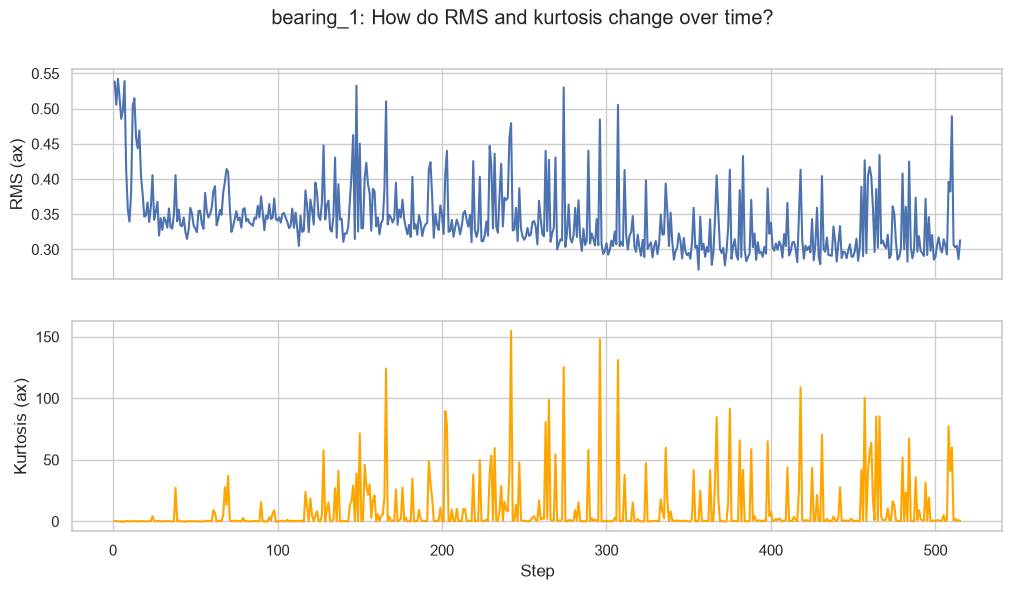

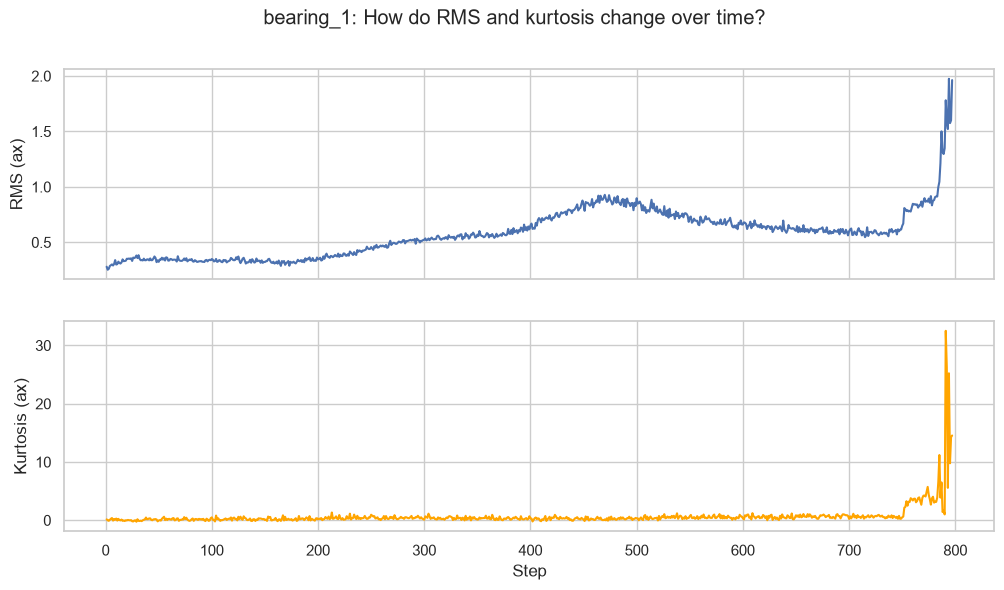

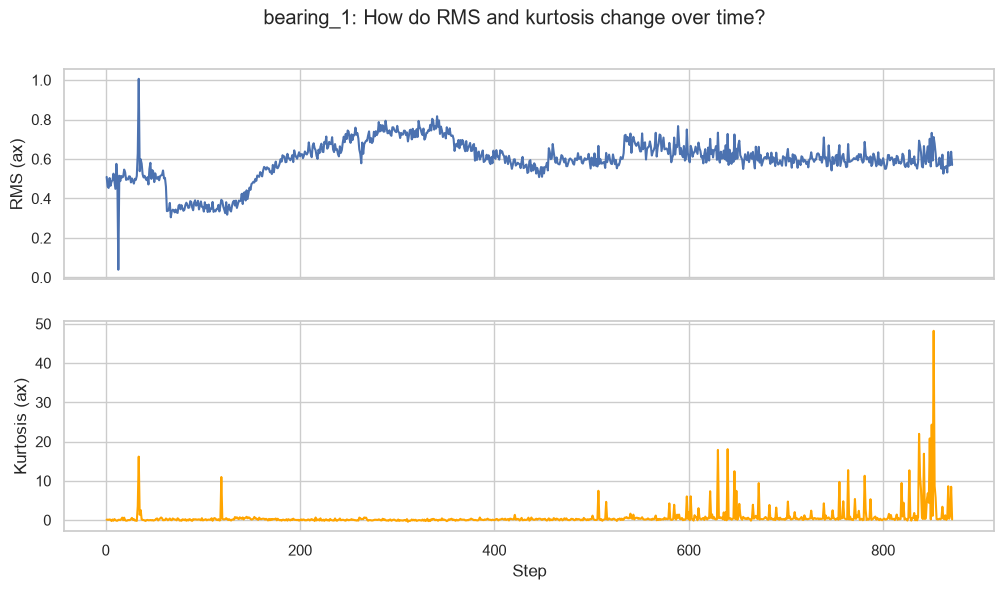

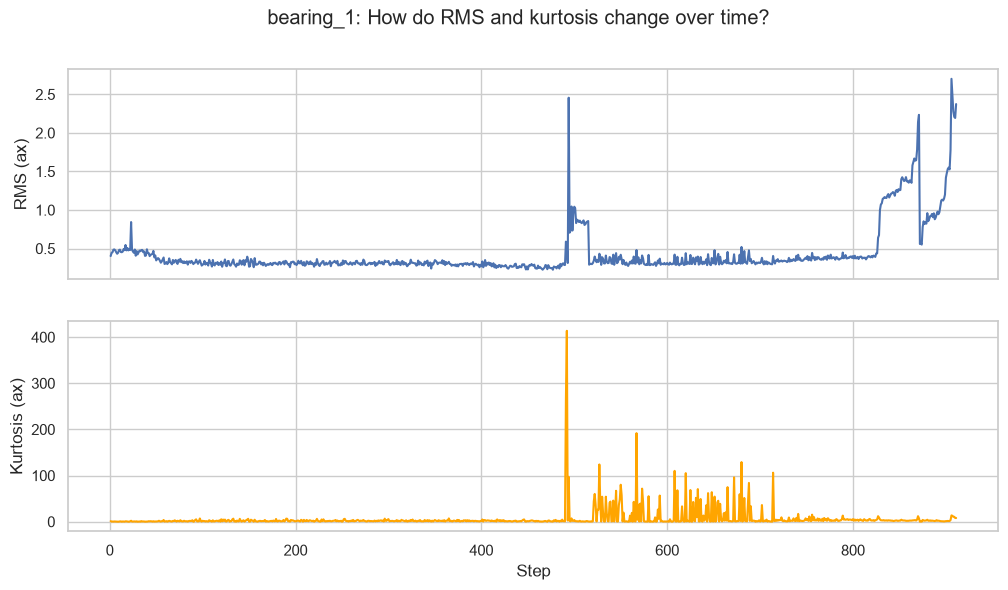

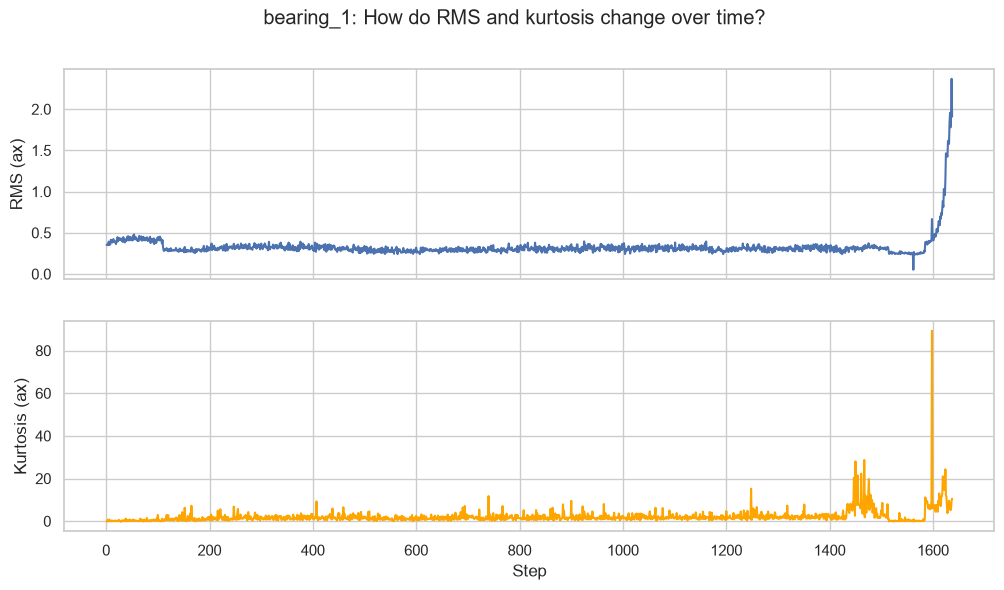

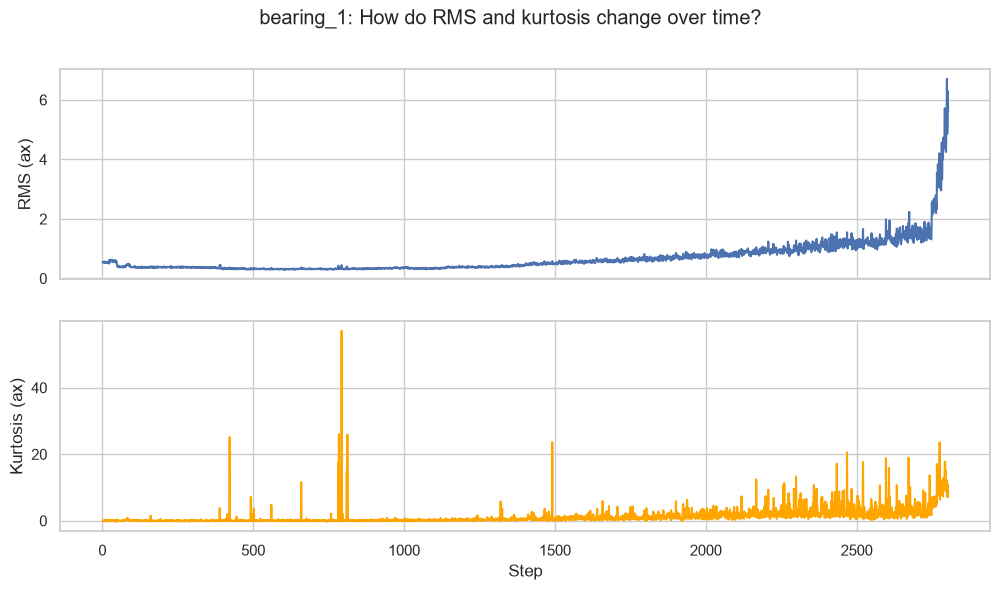

In [56]:
for idx, bearing_id in enumerate(unique_bearings):
    t_data_id = features_train_data[features_train_data['bearing_id'] == bearing_id]
    steps_with_features(t_data_id, idx)

In [59]:
def steps_with_features(train_data: pd.DataFrame, idx: int, bearing_id: str):
    fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)
    axes[0].plot(train_data['step'], train_data['rms_ax'])
    axes[0].set_ylabel('RMS (ax)')
    axes[1].plot(train_data['step'], train_data['kurtosis_ax'], color='orange')
    axes[1].set_ylabel('Kurtosis (ax)')
    axes[1].set_xlabel('Step')
    plt.suptitle(f'{bearing_id}: How do RMS and kurtosis change over time?')
    
    plt.savefig(f"C:\\Users\\elmaz\\AIProject\\NASA_Project\\assumptions\\{bearing_id}_rms_kurtosis.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)



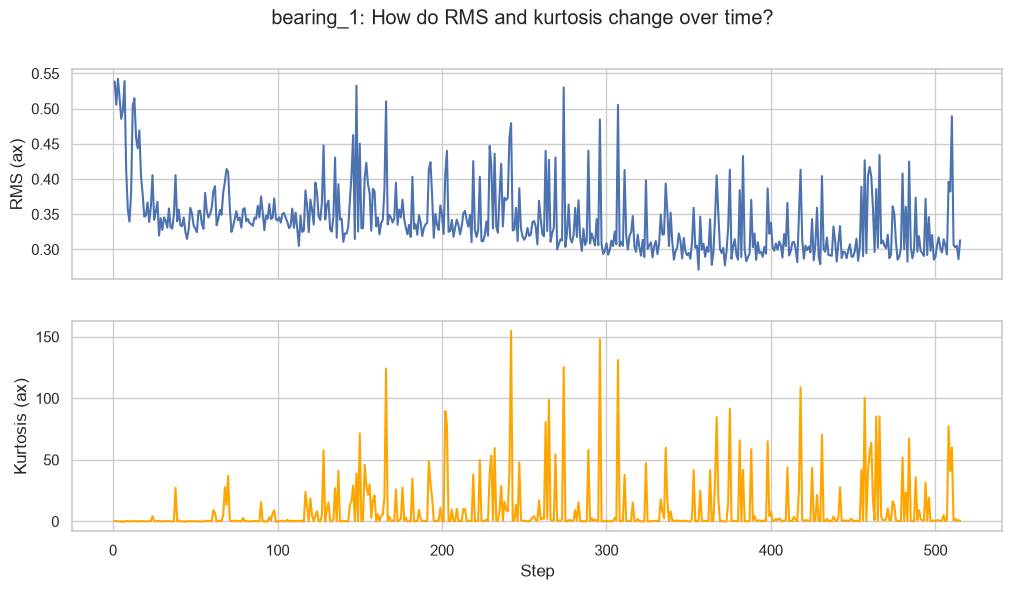

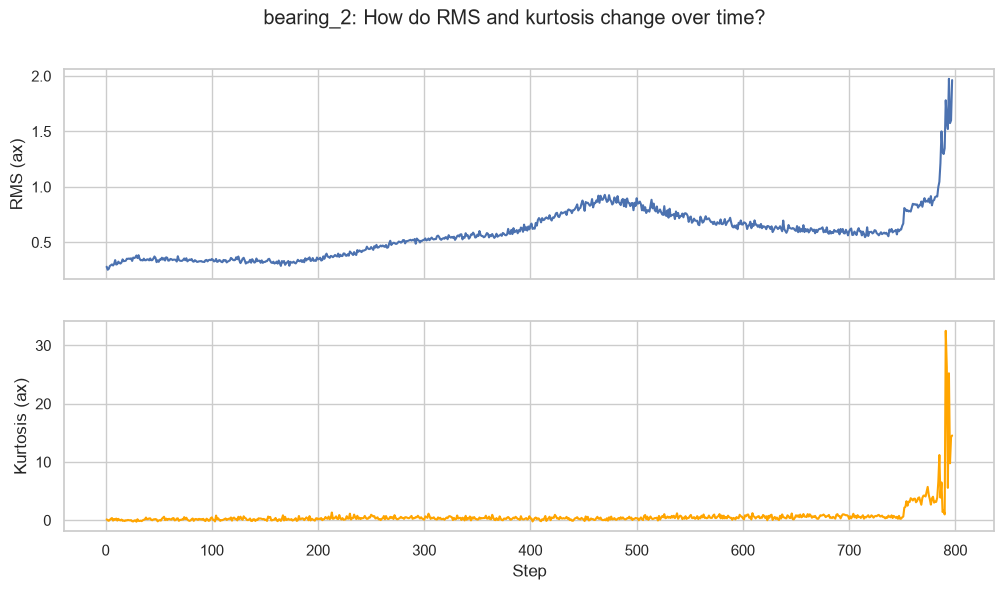

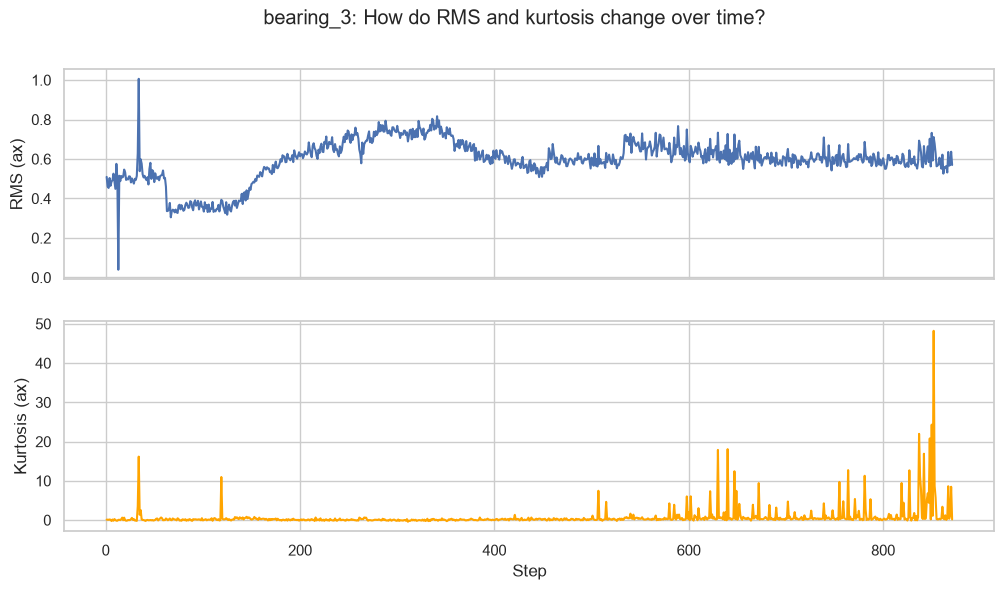

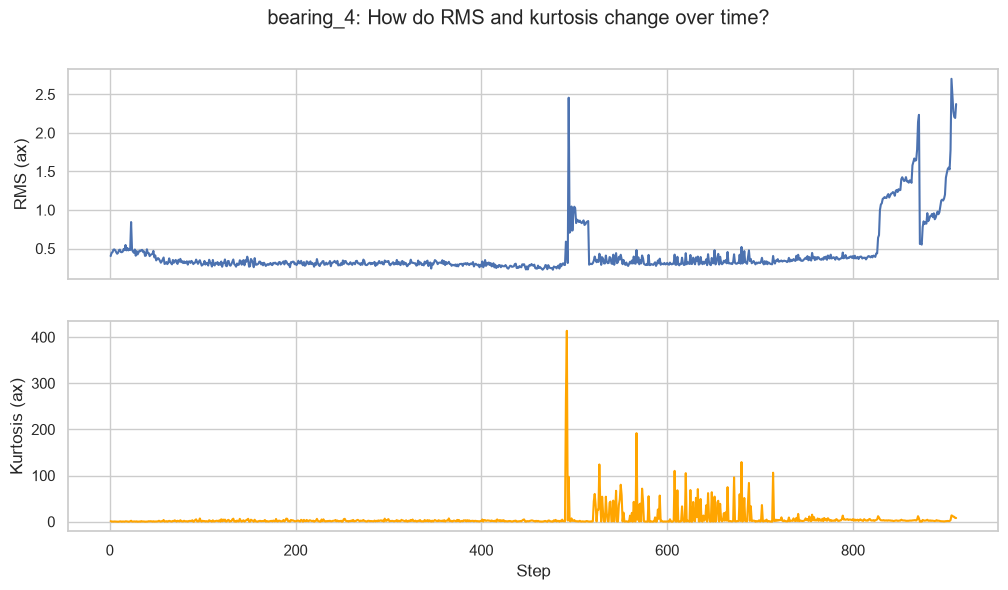

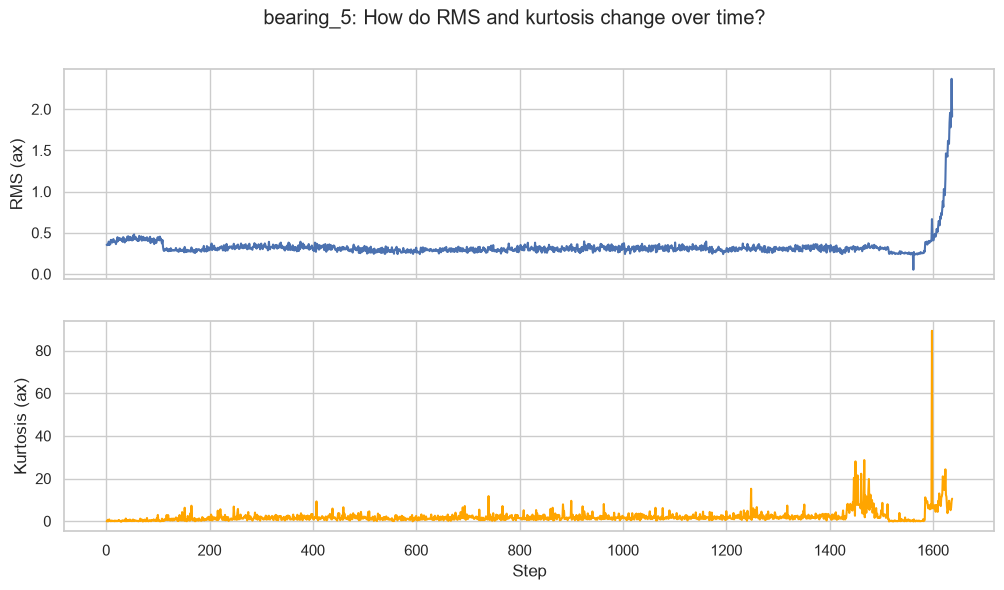

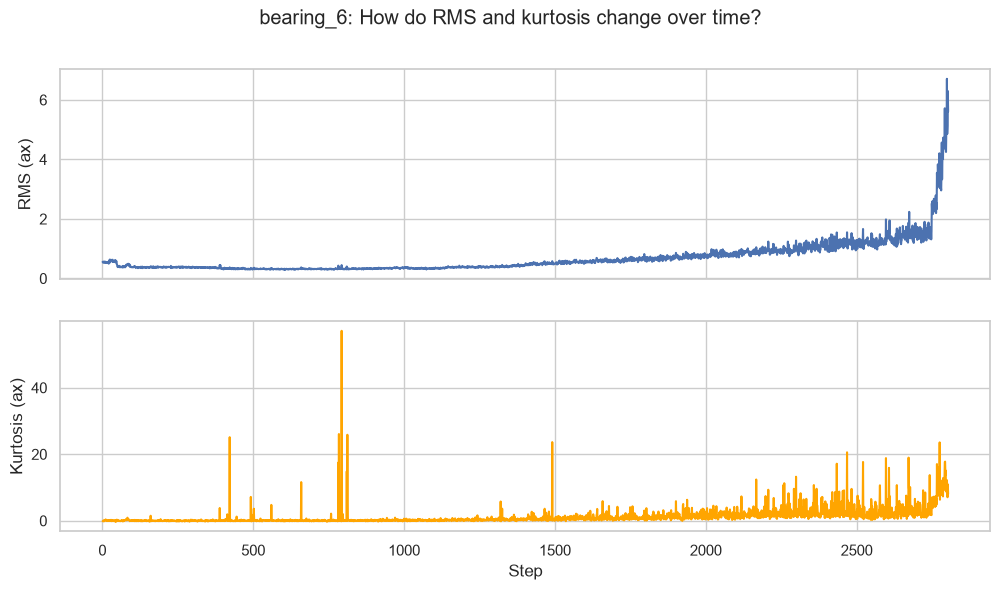

In [60]:
for idx, bearing_id in enumerate(unique_bearings):
    t_data_id = features_train_data[features_train_data['bearing_id'] == bearing_id]
    steps_with_features(t_data_id, idx, bearing_id)